# Lecture 3 — Continuous Opacity

*Stellar Spectroscopy from Scratch — rebuilding the physics of ATLAS and SYNTHE from first principles*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*Every result in this book is checked against reference values computed with [**pykurucz**](https://arxiv.org/abs/2603.11693) — a pure-Python implementation of Kurucz's ATLAS12 and SYNTHE — shipped beside the lectures as small data files, so the notebooks need only NumPy to run.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Distinguish **true absorption** from **scattering**, and write the continuous extinction coefficient per gram.
- Explain why the **negative hydrogen ion H$^-$** dominates the visible continuum of a cool star, and compute its abundance from the Saha equation.
- Evaluate the **H$^-$ bound-free and free-free** opacity with the standard analytic fits (John 1988), add Rayleigh and Thomson scattering, and reproduce the reference continuum to a few percent.
- Say what those analytic fits leave out, and why a **tabulated** engine is needed for bit-level agreement with the production code.
- Build the production engine: the **edge-triplet frequency grid**, the table lookups (`MAP1`, `linter`, the Karzas–Latter hydrogen tables, the Coulomb Gaunt factor, the Gavrila $G^2$ Rayleigh tables), and the **3-point Lagrange interpolation** that reconstructs the opacity at any wavelength.
- Reproduce the reference continuum, $\kappa^{\rm abs}_{\rm cont}$ and $\kappa^{\rm scat}_{\rm cont}$, to **machine precision** through the photosphere — and read the one honest residual in the deep, hot layers below it.

## Introduction

With the equation of state in hand we can finally compute an opacity. Opacity comes in two flavours, and the distinction matters for radiative transfer later. **True absorption** couples the photon to the material energy reservoir of the gas; in LTE, detailed balance makes the thermal emissivity satisfy $S_\lambda = B_\lambda$, so the absorptive part re-emits according to the local temperature. **Scattering** merely redirects a photon without exchanging energy with the gas — the source function then depends on the radiation field itself. (The total source function later mixes the two; that coupling is the whole subject of the JOSH lecture.) This lecture builds the **continuous** opacity: the smooth, slowly-varying background that sets the overall brightness of the star and the floor from which the sharp spectral lines are carved.

We build it twice, at two levels of fidelity. The first half is the **physics**: we identify the dominant absorber, compute its abundance, evaluate its cross-section with the standard analytic fits, and reproduce the reference continuum to **a few percent** — the right level to understand *why* the continuum looks as it does. The second half is the **exact engine**: the production code (`compute_kapp_continuum`, **KAPP** for short) never uses analytic fits; it reads tabulated cross-sections and a fixed interpolation, and we rebuild that table-by-table to reproduce the reference to **machine precision through the photosphere** (with one honest residual in the deep, hot layers below it). This is the same two-stage structure the radiative-transfer lectures use — the physical picture first (Lecture 7, the formal solution), then the production engine that closes the last gap (Lecture 8, JOSH).

## The dominant absorber: the negative hydrogen ion

In a cool star like the Sun the dominant continuous absorber is one of the more surprising species in astrophysics: the **negative hydrogen ion, H$^-$** — a neutral hydrogen atom that has captured a *second*, very loosely bound electron. It binds that electron by only $0.754\ \mathrm{eV}$, so it is fragile and rare, but neutral hydrogen is so overwhelmingly abundant, and the free electrons supplied by the metals (Lecture 2) so available, that in solar-type photospheric layers H$^-$ swamps every other source of optical continuous opacity. We build it, the scattering terms, and the total — and check each against the reference.

Set up the imports and plotting defaults, load the reference continuum grid (`L3.npz`), and define a small `compare` helper we reuse throughout: it takes our opacity and the reference, guards the divide-by-zero where the reference is zero, and prints the worst relative difference with a pass/fail tag.

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})

# the pedagogical continuum grid
REF = np.load(pathlib.Path("..") / "reference" / "L3.npz")


def compare(name, ours, ref, tol=1e-6):
    """Report the worst relative difference between our opacity and the reference."""
    ours, ref = np.asarray(ours, float), np.asarray(ref, float)

    # guard the divide-by-zero where the reference is zero
    denom = np.where(ref != 0.0, np.abs(ref), 1.0)

    rel = float(np.max(np.abs(ours - ref) / denom))
    tag = "exact" if rel < 1e-12 else ("agree" if rel < tol else "CHECK")
    print(f"{name:30s}  max|rel diff| = {rel:.2e}   [{tag}]")
    return rel

Unpack the arrays we need from the reference file — the wavelength and temperature grids, the populations from the equation of state (Lecture 2), the optical-depth scale (Lecture 1) — and set the CGS constants. The temperature, densities, and populations are reshaped to broadcast over the wavelength axis.

In [2]:
# the grids and populations, reshaped (where needed) to broadcast over the wavelength axis
wl  = REF["wl"]                  # [nm]
T   = REF["T"][:, None]          # [K]
n_e = REF["n_e"][:, None]        # [cm^-3]
rho = REF["rho"][:, None]        # [g cm^-3]
nHI = REF["nHI"][:, None]        # neutral H number density [cm^-3]

# Rosseland optical depth and column mass
tau, rhox = REF["tau"], REF["rhox"]

# physical constants, CGS: Planck, c, Boltzmann
H, C, K = 6.62607015e-27, 2.99792458e10, 1.380649e-16

# eV-per-K conversion; Saha (2pi m_e k/h^2)^3/2 prefactor
KEV, SAHA = 1.0/11604.5, 2.4148e15

# frequency [Hz] at each wavelength
nu = C / (wl[None, :] * 1e-7)

print(f"continuum grid: {REF['absorption'].shape[0]} layers x {wl.size} wavelengths, "
      f"{wl[0]:.0f}-{wl[-1]:.0f} nm")

continuum grid: 80 layers x 200 wavelengths, 500-510 nm


## The stimulated-emission factor

Every true-absorption coefficient carries a correction we met in Lecture 1. The radiation field stimulates the inverse radiative process — a downward, emitting transition — alongside the upward, absorbing one; the net absorption is the upward rate minus this stimulated downward rate. (This applies to bound-free and free-free as well as bound-bound, so the emitting electron need not be bound.) For a process in LTE the correction multiplies the raw cross-section by

$$
\big(1 - e^{-h\nu/kT}\big),
$$

the same factor that appears when the Planck denominator is rewritten as $e^{h\nu/kT}(1-e^{-h\nu/kT})$. It is near $1$ in the blue and drops toward the infrared, where $h\nu \lesssim kT$. Scattering, which does not exchange energy with the gas, carries no such factor.

In [3]:
# stimulated-emission correction, shape (layers, wl)
stim = 1.0 - np.exp(-H * nu / (K * T))

print(f"stimulated-emission factor at 505 nm: {stim[:,100].min():.3f} (hot, deep) .. {stim[:,100].max():.3f} (cool)")

stimulated-emission factor at 505 nm: 0.611 (hot, deep) .. 0.998 (cool)


## How much H$^-$ is there? The Saha balance

H$^-$ forms and is destroyed by the reaction $\mathrm{H} + e^- \rightleftharpoons \mathrm{H}^-$, so its abundance follows a Saha equation exactly like the ones in Lecture 2, but with the tiny binding energy $\chi = 0.754\ \mathrm{eV}$ in place of an ionization potential:

$$
\frac{n(\mathrm{H\,I})\,n_e}{n(\mathrm{H}^-)}
= \frac{2\,g_{\rm H\,I}}{g_{\mathrm{H}^-}}
\left(\frac{2\pi m_e kT}{h^2}\right)^{3/2} e^{-\chi/kT},
$$

with statistical weights $g_{\rm H\,I}=2$ (the hydrogen ground state) and $g_{\mathrm{H}^-}=1$ (the closed-shell ion), so the leading factor is $2\cdot2/1 = 4$. Solving for the H$^-$ density,

$$
n(\mathrm{H}^-) = \frac{n(\mathrm{H\,I})\,n_e}{4\,(2.4148\times10^{15})\,T^{3/2}}\;e^{+\chi/kT}.
$$

The positive exponent says H$^-$ is *favoured* at low temperature — the captured electron is more easily held when there is less thermal energy to knock it loose. And the explicit $n_e$ is why H$^-$ opacity tracks the electron density, and hence the metal abundance, that Lecture 2 worked out. This single balance — the $0.754\ \mathrm{eV}$ detachment energy, the Saha prefactor, the $n_e$ scaling — governs the H$^-$ opacity in *both* halves of this lecture: the analytic fit below and the tabulated engine that follows reuse exactly this population, so we derive it once, here.

![The H$^-$ ion — a hydrogen atom holding a second, weakly bound electron (0.754 eV) — is the dominant continuous absorber in cool stars; a photon detaches the electron, and its abundance tracks the electron density.](resources/figures/s3_hminus.png)

In [4]:
chi_Hminus = 0.754   # H- electron binding energy [eV]

# the Saha balance, solved for the H- density [cm^-3]
n_Hminus = nHI * n_e * np.exp(chi_Hminus / (KEV * T)) / (4.0 * SAHA * T**1.5)

print(f"n(H-)/n(H I) at the photosphere: {(n_Hminus/nHI)[50,0]:.2e}  "
      f"(about two H- per billion H atoms)")

n(H-)/n(H I) at the photosphere: 1.96e-09  (about two H- per billion H atoms)


## The analytic approach: H$^-$ bound-free and free-free (John 1988)

H$^-$ absorbs by two channels. **Bound-free** (photodetachment) ejects the bound electron, $\mathrm{H}^- + \gamma \to \mathrm{H} + e^-$; it has a threshold at $\lambda_0 = 1.6419\ \mathrm{\mu m}$ (corresponding to $0.754\ \mathrm{eV}$) and peaks in the red. **Free-free** is absorption by a passing electron in the field of a neutral hydrogen atom, $\mathrm{H} + e^- + \gamma \to \mathrm{H} + e^-$; it has no threshold and rises into the infrared.

For both we use the standard analytic fits of **John (1988)**, accurate to $\sim1\%$ over their fitted range and used throughout stellar-atmosphere work — though, as the second half will show, not identical to the Kurucz production tables. The bound-free photodetachment cross-section, with $\lambda$ in microns and $f \equiv 1/\lambda - 1/\lambda_0$, is

$$
\sigma_{\rm bf}(\lambda) = 10^{-18}\,\lambda^3\,f^{3/2}\sum_{n=0}^{5} C_n\, f^{n/2}\quad[\mathrm{cm^2}],
$$

and the opacity per gram is $\kappa_{\rm bf} = n(\mathrm{H}^-)\,\sigma_{\rm bf}\,(1-e^{-h\nu/kT})/\rho$. The free-free coefficient is a temperature- and wavelength-polynomial in $\theta = 5040/T$, returning the absorption per neutral H atom per unit electron pressure $P_e = n_e kT$. John's free-free fit is tabulated in the net-absorption convention the production code uses, so no separate $1-e^{-h\nu/kT}$ multiplier is applied to it — the stimulated-emission correction is already folded into the polynomial.

In [5]:
# John (1988) H- bound-free photodetachment cross-section
lam_um = wl[None, :] * 1e-3   # [um]
lam0 = 1.6419                 # threshold [um] (0.754 eV)

# the "distance past threshold" variable
f = 1.0/lam_um - 1.0/lam0

# John's polynomial coefficients, and the half-integer power series in f
C_bf = [152.519, 49.534, -118.858, 92.536, -34.194, 4.982]
poly = sum(C_bf[n] * f**(n/2.0) for n in range(6))

# cross-section, zero beyond threshold [cm^2]
sigma_bf = np.where(lam_um < lam0, 1e-18 * lam_um**3 * f**1.5 * poly, 0.0)

# opacity per gram, with the stimulated-emission factor [cm^2/g]
kappa_bf = n_Hminus * sigma_bf * stim / rho

The free-free coefficient is the second John (1988) polynomial: a double power series in $\theta=5040/T$ and in inverse wavelength. It returns the absorption per neutral H atom per unit electron pressure $P_e = n_e kT$, so we multiply by $P_e$ and the neutral-H density to get the opacity per gram. (No explicit stimulated-emission factor — it is already folded into John's fit, as noted above.)

In [6]:
# John (1988) H- free-free coefficient (lambda > 0.3645 um branch), per H I atom per unit P_e.
# The six coefficient rows (A..F) are the double power series in theta and inverse wavelength.
A=[0,2483.346,-3449.889,2200.040,-696.271,88.283]; B=[0,285.827,-1158.382,2427.719,-1841.400,444.517]
Cc=[0,-2054.291,8746.523,-13651.105,8624.970,-1863.864]; D=[0,2827.776,-11485.632,16755.524,-10051.530,2095.288]
E=[0,-1341.537,5303.609,-7510.494,4400.067,-901.788]; F=[0,208.952,-812.939,1132.738,-655.020,132.985]

theta = 5040.0 / T   # the John temperature variable
kff = sum(theta**((n+1)/2.0) * (A[n]*lam_um**2 + B[n] + Cc[n]/lam_um + D[n]/lam_um**2
                                + E[n]/lam_um**3 + F[n]/lam_um**4) for n in range(1, 6))

# multiply by the electron pressure and the neutral-H density to get the opacity per gram
P_e = n_e * K * T   # electron pressure [dyn cm^-2]
kappa_ff = 1e-29 * kff * P_e * nHI / rho   # [cm^2/g]

# total analytic H- absorption
kappa_Hminus = kappa_bf + kappa_ff

Benchmark the analytic H$^-$ against the reference — but only over the layers where the optical spectrum forms. H$^-$ dominates there; far deeper, hydrogen and metal bound-free edges take over from it, and this analytic model does not carry them.

In [7]:
# H- dominates only where the optical spectrum forms; deep, hot layers add H and metal
# bound-free that this analytic model is not carrying, so we benchmark over the forming layers.
form = (tau > 1e-3) & (tau < 3.0)   # the spectrum-forming optical-depth window

rel = np.abs(kappa_Hminus[form] - REF["absorption"][form]) / REF["absorption"][form]
print(f"continuum absorption (H-), spectrum-forming layers:  "
      f"median|rel diff| = {np.median(rel):.2e}   max = {np.max(rel):.2e}")

continuum absorption (H-), spectrum-forming layers:  median|rel diff| = 2.97e-02   max = 1.06e-01


About two percent through the layers where the optical spectrum forms — our textbook H$^-$ reproduces the reference absorption, the bound-free channel carrying most of it at these wavelengths. Two honest caveats. The residual is the detailed photodetachment table the production code carries — which the exact engine in the second half of this lecture evaluates directly. And we restrict the comparison to the spectrum-forming layers on purpose: far below the photosphere (deeper than $\tau_{\rm Ross}\sim 5$, hotter than $\sim10{,}000\ \mathrm{K}$) hydrogen and metal bound-free edges take over from H$^-$, but those layers are never seen in the emergent optical spectrum, so the analytic model does not bother with them. Where it matters, H$^-$ alone carries the continuous absorption of the solar photosphere.

## Scattering: Rayleigh beats Thomson

Now the scattering. The textbook reflex is **Thomson scattering** off free electrons, with the constant cross-section $\sigma_T = 0.6653\times10^{-24}\ \mathrm{cm^2}$. But in a cool photosphere the free electrons are scarce ($n_e \sim 10^{13}\ \mathrm{cm^{-3}}$, Lecture 2), while neutral hydrogen is everywhere. **Rayleigh scattering** off the bound electrons of neutral hydrogen — the same kind of $\lambda^{-4}$ scattering off bound electrons that makes Earth's sky blue (there off air molecules, here off neutral H) — therefore dominates. We use the standard polarizability fit (Dalgarno), with $\lambda$ in ångström,

$$
\sigma_{\rm Ray}(\lambda) = \frac{5.799\times10^{-13}}{\lambda^4} + \frac{1.422\times10^{-6}}{\lambda^6} + \frac{2.784}{\lambda^8}\quad[\mathrm{cm^2}],
$$

and add Thomson for completeness. Neither carries a stimulated-emission factor.

In [8]:
lamA = wl[None, :] * 10.0   # [angstrom]

# Rayleigh off neutral H (Dalgarno fit) and grey Thomson off electrons
sigma_Ray = 5.799e-13/lamA**4 + 1.422e-6/lamA**6 + 2.784/lamA**8   # [cm^2] per H I atom
kappa_Ray = sigma_Ray * nHI / rho   # [cm^2/g]
kappa_Thomson = 0.6653e-24 * n_e / rho * np.ones_like(nu)
kappa_scat = kappa_Ray + kappa_Thomson

compare("scattering (Rayleigh+Thomson)", kappa_scat, REF["scattering"], tol=5e-2)
print(f"at the photosphere, Rayleigh is {kappa_Ray[50,100]/kappa_Thomson[50,100]:.0f}x Thomson; "
      f"scattering is {100*kappa_scat[50,100]/kappa_Hminus[50,100]:.0f}% of absorption")

scattering (Rayleigh+Thomson)   max|rel diff| = 1.14e-02   [agree]
at the photosphere, Rayleigh is 9x Thomson; scattering is 2% of absorption


Rayleigh outweighs Thomson roughly tenfold at this layer, and scattering as a whole is only a couple of percent of the H$^-$ absorption — the solar optical continuum is an *absorption* continuum, which is why its source function stays close to the Planck function rather than a scattering-dominated one, and the emergent continuum intensity closely samples $B_\lambda[T(\tau_\lambda\!\sim\!1)]$ at the H$^-$-set formation depth. The precise Rayleigh/Thomson split is depth- and atmosphere-dependent (it tracks the neutral-H to free-electron ratio): this analytic atmosphere point gives roughly $10:1$, while the representative deeper layer used in the exact-engine budget later runs closer to $2:1$. In the ultraviolet, where $\lambda^{-4}$ Rayleigh climbs and metal photoionization switches on, the balance shifts; in hot stars, where hydrogen is ionized, Thomson takes over.

## The total continuum and where it forms

Add absorption and scattering for the total continuous extinction, and check it against the reference. Then convert it to optical depth. Here `rhox` is the inward column mass $m=\int\rho\,dz$, so $d\tau_\lambda = \kappa_\lambda\,\rho\,dz = \kappa_\lambda\,dm$; integrating the continuum opacity over the column mass tells us the depth from which the continuum escapes — and confirms the Eddington–Barbier picture of Lecture 1.

In [9]:
# total continuous extinction
kappa_total = kappa_Hminus + kappa_scat
ref_total = REF["absorption"] + REF["scattering"]

rel = np.abs(kappa_total[form] - ref_total[form]) / ref_total[form]
print(f"total continuum, spectrum-forming layers:  "
      f"median|rel diff| = {np.median(rel):.2e}   max = {np.max(rel):.2e}")

# continuum optical depth at mid-window (505 nm), integrated over column mass via the trapezoid rule
k505 = kappa_total[:, 100]
tau_cont = np.zeros_like(rhox)
tau_cont[1:] = np.cumsum(0.5*(k505[1:]+k505[:-1]) * np.diff(rhox))

# the layer where the continuum reaches tau=2/3
j23 = np.argmin(np.abs(tau_cont - 2/3))
print(f"the 505 nm continuum reaches tau=2/3 at T = {REF['T'][j23]:.0f} K  "
      f"(log tau_Ross = {np.log10(tau[j23]):.2f})")

total continuum, spectrum-forming layers:  median|rel diff| = 2.41e-02   max = 1.06e-01
the 505 nm continuum reaches tau=2/3 at T = 6744 K  (log tau_Ross = 0.25)


Plot the opacity against depth (showing how H$^-$ absorption and scattering each contribute) and the integrated continuum optical depth (locating the $\tau=2/3$ surface).

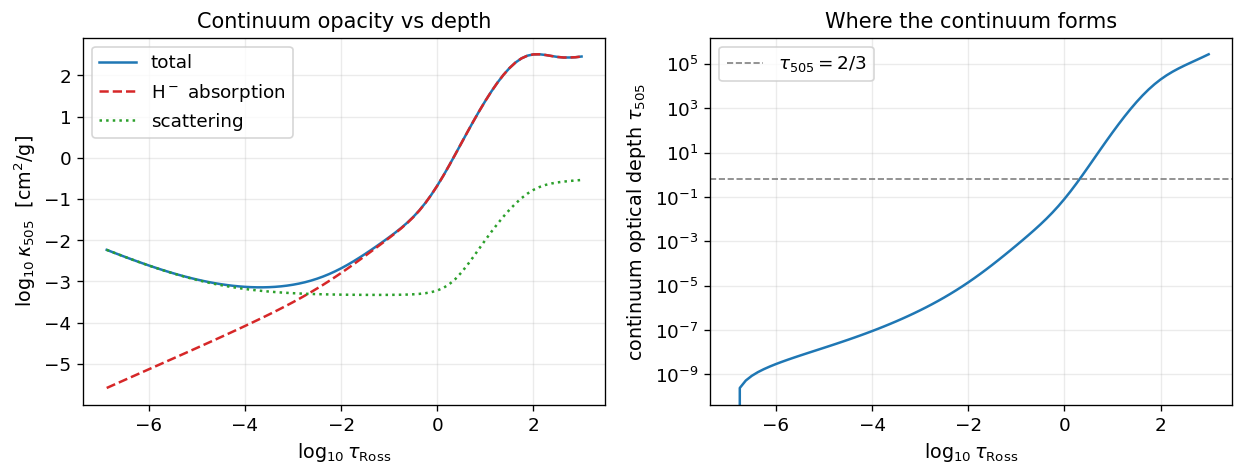

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.1))

# left: the opacity vs depth, split into absorption and scattering
ax[0].plot(np.log10(tau), np.log10(kappa_total[:,100]), color="C0", label="total")
ax[0].plot(np.log10(tau), np.log10(kappa_Hminus[:,100]), "--", color="C3", label="H$^-$ absorption")
ax[0].plot(np.log10(tau), np.log10(kappa_scat[:,100]), ":", color="C2", label="scattering")
ax[0].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$")
ax[0].set_ylabel(r"$\log_{10}\kappa_{505}$  [cm$^2$/g]")
ax[0].set_title("Continuum opacity vs depth")
ax[0].legend()

# right: the integrated continuum optical depth, locating the tau=2/3 surface
ax[1].plot(np.log10(tau), tau_cont, color="C0")
ax[1].axhline(2/3, ls="--", color="0.5", lw=1, label=r"$\tau_{505}=2/3$")
ax[1].set_yscale("log")
ax[1].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$")
ax[1].set_ylabel(r"continuum optical depth $\tau_{505}$")
ax[1].set_title("Where the continuum forms")
ax[1].legend()

fig.tight_layout(); plt.show()

The total continuum matches the reference to about two percent through the spectrum-forming layers — the level at which clean textbook opacity reproduces a production code, the residual being the detailed cross-section tables it carries. The right-hand panel locates the continuum's origin: at $505\ \mathrm{nm}$ it forms around $T\approx6700\ \mathrm{K}$ — close to the real solar value, and somewhat hotter than the grey $\tau_{\rm Ross}=2/3$ photosphere ($5800\ \mathrm{K}$). That offset is a symptom of the crude grey temperature structure and its placeholder Rosseland opacity ($\kappa\equiv1$); Lectures 9–10 rebuild both self-consistently and the depth scales fall into line. The point stands: the continuum opacity sets which layer — and so which temperature — the brightness reflects.

We now have the physics, right to a couple of percent. The residual is not random error — it is the gap between an analytic fit and the **detailed cross-section tables** the production code carries. The rest of this lecture closes that gap.

---

## The exact engine: from a few percent to the bit

The first half built the continuous opacity the way one builds intuition: the H$^-$ ion dominates, so we evaluated its cross-sections with the **analytic fits** of John (1988), added Rayleigh and Thomson scattering, and reproduced the reference to **a few percent**. That is the right level for understanding *why* the continuum looks as it does. It is not the level at which the production code works.

The production engine — `compute_kapp_continuum` in the Kurucz codes, **KAPP** for short — does not use analytic fits. It evaluates every continuum source from a **tabulated cross-section** stored as a data table, and the analytic fits agree with those tables only to a couple of percent — exactly the gap the first half left. This is the **exact-engine counterpart** to the physics above, the same way JOSH (Lecture 8) is the exact engine behind the formal solution (Lecture 7). We keep the physical picture — H$^-$ dominates, scattering is a percent-level floor, the Saha balance of the previous section sets the H$^-$ population — and replace each analytic fit with a clean evaluation of the production table. The two stages are: evaluate every source on a small **edge-triplet frequency grid** (three frequencies per continuum interval), then **interpolate** to the wavelengths we want. The payoff is the continuum reproduced to machine precision through the entire photosphere.

## Why a tabulated engine, and what the fits miss

To reproduce the reference *to the bit* we evaluate the same tables, with the same interpolation, in the same order. Three things separate the tabulated engine from the analytic fits:

- **The table itself.** H$^-$ bound-free is stored as 85 sampled cross-sections versus wavelength; the engine interpolates the table directly with the Kurucz `MAP1` parabola, not a closed-form polynomial. Where John's fit and the table disagree by a percent, the engine follows the table.
- **The minor absorbers.** At 500–510 nm the H$^-$ ion supplies $\sim$92% of the absorption, but the remaining $\sim$8% is real and structured: H I bound-free and free-free, the H$_2^+$ molecular ion, and small bound-free edges of Mg I, Al I, Si I. The physics half folded these into "a few percent"; the engine evaluates each one.
- **The interpolation.** The engine never evaluates opacity at the synthesis wavelengths directly. It samples three frequencies per continuum **edge interval**, then reconstructs the wavelength dependence by a fixed 3-point Lagrange parabola. Matching the reference means matching that interpolation exactly.

Here is the roadmap for the half — every absorption source we evaluate, the physical process, the population it needs, the table or interpolator that reads it, and its rough share of the absorption at 505 nm:

| source | process | population | table / interpolator | share at 505 nm |
|---|---|---|---|---|
| H$^-$ | bound-free + free-free | ground-state H I, $n_e$ | `HMINOP` (`MAP1` + `linter`) | $\sim$92% |
| H I | bound-free + free-free | ground-state H I + Boltzmann factors for the excited levels; H II and $n_e$ for free-free | Karzas–Latter (`xkarsas`) + `COULFF` | $\sim$2% |
| H$_2^+$, He, C/Mg/Al/Si | molecular + bound-free edges | He I, metal populations | analytic + edge tables | $\sim$6% |
| He, hot-star, Si II | bound-free + free-free | He I/II/III, charge sums | `HE1OP`/`HE2OP`, `HOTOP`, `LUKEOP` | $\lesssim 10^{-5}$ |
| Rayleigh + Thomson | scattering | ground-state H I, $n_e$ | Gavrila $G^2$ + classical $\sigma_e$ | (the scattering coefficient) |

**Notation reset.** The two halves use different data files and variable names. The first half loaded the pedagogical continuum grid `REF` (with `wl`, `T`); the engine half loads three production files: `A` = the atmosphere/EOS (populations, edge grid), `D` = the reference diagnostic continuum (`diag.npz`, ground truth), and `KT` = the cross-section tables. Wavelengths are `wlk`, temperature `Tk`. Load them now.

In [11]:
# A = atmosphere / EOS populations (80 layers); D = the reference continuum (ground truth);
# KT = the atomic cross-section tables
A = np.load(pathlib.Path("..") / "reference" / "atmosphere.npz", allow_pickle=True)
D = np.load(pathlib.Path("..") / "reference" / "diag.npz")
KT = np.load(pathlib.Path("..") / "reference" / "kapp_tables.npz")

wlk       = D["wavelength"]               # [nm], 500-510 nm synthesis grid
cabs_ref  = D["continuum_absorption"]     # kappa_abs  (depth, wl), [cm^2/g]
cscat_ref = D["continuum_scattering"]     # kappa_scat (depth, wl), [cm^2/g]
Tk        = A["temperature"]              # [K], 80 layers, surface -> deep
n_layers  = Tk.size

print(f"continuum reference: {cabs_ref.shape[0]} layers x {wlk.size} wavelengths, "
      f"{wlk[0]:.1f}-{wlk[-1]:.1f} nm")
print(f"atmosphere spans T = {Tk.min():.0f} .. {Tk.max():.0f} K")

continuum reference: 80 layers x 5941 wavelengths, 500.0-510.0 nm
atmosphere spans T = 4680 .. 30201 K


## Constants and the cross-section tables

The engine uses the same physical constants as the rest of the pipeline (CGS, with the Fortran code's exact values so the arithmetic matches bit for bit). The tables come in two groups. The **Karzas–Latter** group (`FREQ_LOG`, `XN_LOG`, `XL_LOG_ARRAY`, `EKARSAS`) holds the hydrogen bound-free cross-sections on a $\log_{10}(\nu/Z_{\rm eff}^2)$ grid. The **KAPP** group holds everything else: the H$^-$ bound-free table (`HMINOP_WBF`, `HMINOP_BF`), the H$^-$ free-free table (`HMINOP_FFBEG`, `HMINOP_FFEND` on the `HMINOP_WAVEK`$\times$`HMINOP_THETAFF` grid), the Gavrila Rayleigh tables (`HRAYOP_*`), the Coulomb free-free Gaunt-factor table (`COULFF_A_TABLE`, `COULFF_Z4LOG`), and the small-contributor tables (`HOTOP_TRANSITIONS`, the Si II Peach tables, the hydrogen partition-function inputs).

In [12]:
# ── the hydrogen group: Karzas-Latter bound-free + the H- tables ──
FREQ_LOG = KT["FREQ_LOG"]              # (29,15) descending log10(freq/zeff^2) grid (Karzas-Latter)
XN_LOG = KT["XN_LOG"]                  # (29,15) log10 cross-section, l-summed
XL_LOG_ARRAY = KT["XL_LOG_ARRAY"]      # (6,6,29) l-resolved log10 cross-section
EKARSAS = KT["EKARSAS"]                # (29,) excitation energies (n>15 branch)
HMINOP_WBF = KT["HMINOP_WBF"]          # (85,) wavelength [nm] for H- bf MAP1
HMINOP_BF = KT["HMINOP_BF"]            # (85,) H- bf cross-section [1e-18 cm^2]
HMINOP_WAVEK = KT["HMINOP_WAVEK"]      # (22,) WAVEK grid for H- ff
HMINOP_THETAFF = KT["HMINOP_THETAFF"]  # (11,) theta=5040/T grid for H- ff
HMINOP_FFBEG = KT["HMINOP_FFBEG"]      # (11,11) H- ff (first 11 wavek columns)
HMINOP_FFEND = KT["HMINOP_FFEND"]      # (11,11) H- ff (last 11 wavek columns)
print("hydrogen / H- tables loaded")

hydrogen / H- tables loaded


The second group is everything else: the Gavrila Rayleigh tables, the Coulomb free-free Gaunt-factor table, and the small-contributor tables (the hot-star transitions, the Si II Peach tables, and the hydrogen partition-function inputs).

In [13]:
# ── the scattering + minor-absorber tables ──
HRAYOP_GAVRILAM = KT["HRAYOP_GAVRILAM"]                  # (74,) visible Rayleigh G
HRAYOP_GAVRILAMAB = KT["HRAYOP_GAVRILAMAB"]              # (27,)
HRAYOP_GAVRILAMBC = KT["HRAYOP_GAVRILAMBC"]              # (24,)
HRAYOP_GAVRILAMCD = KT["HRAYOP_GAVRILAMCD"]              # (22,)
HRAYOP_GAVRILALYMANCONT = KT["HRAYOP_GAVRILALYMANCONT"]    # (64,)
HRAYOP_FGAVRILALYMANCONT = KT["HRAYOP_FGAVRILALYMANCONT"]  # (64,)
COULFF_Z4LOG = KT["COULFF_Z4LOG"]      # (6,)
COULFF_A_TABLE = KT["COULFF_A_TABLE"]  # (12,11) Coulomb ff Gaunt-factor table
HOTOP_TRANSITIONS = KT["HOTOP_TRANSITIONS"]  # (60,7) hot-star bf transitions
_SI2OP_PEACH = KT["_SI2OP_PEACH"]      # (14,6) Si II Peach tables
_SI2OP_FREQSI = KT["_SI2OP_FREQSI"]    # (7,)
_SI2OP_FLOG = KT["_SI2OP_FLOG"]        # (9,)
_SI2OP_TLG = KT["_SI2OP_TLG"]          # (6,)
H_ENERGY_CM = KT["H_ENERGY_CM"]        # (6,) H level energies [cm^-1] (partition function)
H_STAT_WEIGHT = KT["H_STAT_WEIGHT"]    # (6,) H statistical weights
print("scattering / minor-absorber tables loaded")

scattering / minor-absorber tables loaded


Finally the physical constants. They are CGS, fixed to the Fortran code's exact literal values so the arithmetic reproduces the reference bit for bit.

In [14]:
# ── constants (CGS, Fortran values, matching the production code exactly) ──
C_LIGHT_CM = 2.99792458e10                              # speed of light [cm/s]
C_LIGHT_NM = 2.99792458e17                              # speed of light [nm/s]
H_PLANCK = 6.62607015e-27                               # Planck constant [erg s]
K_BOLTZ = 1.380649e-16                                  # Boltzmann constant [erg/K]
KBOLTZ_EV = 8.6171e-5                                   # Boltzmann constant [eV/K]
RYDBERG_CM = 109677.576                                 # Rydberg [cm^-1]
LN10 = np.log(10.0)
H_ENERGY_EV = H_ENERGY_CM / 8065.479                    # H level energies [eV] (from cm^-1)
H_MAX_LEVEL = 6                                          # tabulated H levels for the partition fn
print("constants loaded")

constants loaded


## The edge-triplet frequency grid and the 3-point interpolation

The engine's first design choice is to **not** evaluate opacity at the synthesis wavelengths. Continuum opacity is smooth between **photo-ionization edges** — sharp frequencies (the H$^-$ threshold, the Balmer edge, each metal edge) where a bound-free cross-section switches on. Between two consecutive edges the opacity is a slowly varying curve with no kinks, so the engine samples it at just **three frequencies per edge interval** and reconstructs the curve by a parabola. The motive is speed: evaluating the expensive Gaunt factors and table lookups at $\sim$1,000 edge sample frequencies, then interpolating, is far cheaper than evaluating them at the 100,000+ wavelengths of a high-resolution synthesis grid.

We define **left** and **right** in wavelength: $\lambda_{\rm left}$ is the longer wavelength (the low-frequency end of the interval), $\lambda_{\rm right}$ the shorter wavelength (high frequency) — recall that frequency increases toward shorter wavelength, so $\nu_{\rm left}<\nu_{\rm right}$. The three sample frequencies are the two edges and their midpoint in wavelength, with each edge nudged by one part in $10^7$ *into* the interval so we never evaluate a cross-section exactly on a discontinuity. Nudging inward means lowering the high-frequency edge and raising the low-frequency one:

$$
\nu_0 = \frac{\nu_{\rm right}}{1.0000001}, \qquad
\nu_1 = \frac{c}{(\lambda_{\rm left}+\lambda_{\rm right})/2}, \qquad
\nu_2 = \nu_{\rm left}\times 1.0000001 .
$$

(The factor $1.0000001$ and the inward direction are the Kurucz convention; matching the reference means reproducing them exactly.) The whole continuum across all $\sim$340 edges is therefore $3\times340$ frequencies — but for the 500–510 nm window we need only the **one edge interval** that brackets it. Build the full triplet grid, then find which edge the synthesis wavelengths fall in.

In [15]:
frqedg = A["frqedg"]            # (341,) edge frequencies [Hz]
wledge_signed = A["wledge"]     # (341,) edge wavelengths [nm] (sign flags special edges)
n_edges = frqedg.size

# Three sample frequencies per edge interval: the high-frequency edge nudged inward (down),
# the wavelength midpoint, and the low-frequency edge nudged inward (up). frqedg descends with
# index, so frqedg[i] is the high-frequency edge of the interval and frqedg[i+1] the low one.
freqset = np.empty(3 * (n_edges - 1))
for i in range(n_edges - 1):
    freqset[3*i]     = abs(frqedg[i]) / 1.0000001
    freqset[3*i + 1] = C_LIGHT_NM / ((abs(wledge_signed[i]) + abs(wledge_signed[i+1])) / 2.0)
    freqset[3*i + 2] = abs(frqedg[i+1]) * 1.0000001

# which edge interval does the 500-510 nm grid fall in?
wledge = np.abs(wledge_signed)
edge_idx = np.clip(np.searchsorted(wledge, np.abs(wlk), side="right") - 1, 0, wledge.size - 2)
used_edges = np.unique(edge_idx)
print(f"{n_edges} edges -> {freqset.size} sample frequencies in the full continuum")
print(f"the 500-510 nm window uses edge interval(s): {used_edges}  "
      f"(lambda {wledge[used_edges[0]]:.2f} .. {wledge[used_edges[0]+1]:.2f} nm)")

341 edges -> 1020 sample frequencies in the full continuum
the 500-510 nm window uses edge interval(s): [185]  (lambda 499.65 .. 513.14 nm)


## The populations the engine reads

Every opacity term is a cross-section times a number density divided by the mass density (to get cm$^2$/g). The number densities come from the equation of state of Lecture 2, stored in the atmosphere file. The engine reads them in the production code's two "POPS modes". A **mode-11** quantity is the population of one level of a specific ionization stage, stored in Kurucz's *per-sublevel* convention — that is, already divided by the level's statistical weight $g$ (so `xnfph[:,0]` is the ground-state H I population per sublevel, not the physical number density; the physical density is recovered by multiplying back the ground-state weight $g=2$, which the code does explicitly where needed). A **mode-12** quantity is a stage total (e.g. all neutral hydrogen). H$^-$, for instance, needs ground-state neutral H (mode-11) and the free-electron density — the same Saha population we derived analytically in the first half; H I bound-free needs the same ground-state H; H I free-free needs the proton density.

We gather them into one dictionary, including the helium and metal populations the minor terms use. The departure-coefficient tables `bhyd`, `bmin` (the ratio of the true level population to its LTE value) are all unity here — this model is in LTE — but we carry them so the code reads exactly like the engine, where in a non-LTE model they would differ from one.

In [16]:
# (80, 6, 139): [layer, ion_stage, element]; element 0 = H, 1 = He
pop = A["population_per_ion"]

# gather the populations each opacity term reads into one dictionary
pops = dict(
    temperature=A["temperature"], mass_density=A["mass_density"],
    electron_density=A["electron_density"],
    xnfph=A["xnfph"],               # (80,2): mode-11 (per-sublevel) [ground-state H I, H II]
    xnf_h=A["xnf_h"],               # mode-12: total neutral H (for Rayleigh ground state)
    he1_mode11=pop[:, 0, 1], he2_mode11=pop[:, 1, 1], he3_mode11=pop[:, 2, 1],   # He stages, mode-11
    he1_mode12=A["xnf_he1"], he2_mode12=A["xnf_he2"],                            # He stage totals
    xnfpc=A["xnfpc"], xnfpmg=A["xnfpmg"], xnfpal=A["xnfpal"],                    # metal bf populations
    xnfpsi=A["xnfpsi"], xnfpfe=A["xnfpfe"],
    xnfpn=pop[:, 0, 6], xnfpo=pop[:, 0, 7],
    xnfpmg2=pop[:, 1, 11], xnfpsi2=pop[:, 1, 13], xnfpca2=pop[:, 1, 19],         # singly-ionized metals
)
print("ground-state H I population, mode-11 per sublevel (surface -> deep): "
      f"{pops['xnfph'][0,0]:.3e} .. {pops['xnfph'][-1,0]:.3e} cm^-3")

ground-state H I population, mode-11 per sublevel (surface -> deep): 2.527e+09 .. 6.035e+16 cm^-3


The hot-star term needs two more derived population vectors: a per-transition population array for its bound-free transitions, and the charge-weighted sum $\sum_Z Z^2 n_Z$ over several elements that drives its multi-charge free-free. Both are negligible in the Sun but built so the engine sum is complete.

In [17]:
# HOTOP population vectors (the hot-star bound-free / free-free term; tiny in the Sun)

# per-transition populations for the bound-free table
hotop_xnfp = np.zeros((n_layers, 21))
hotop_xnfp[:, 0:4] = pop[:, 0:4, 5]; hotop_xnfp[:, 4:9] = pop[:, 0:5, 6]
hotop_xnfp[:, 9:15] = pop[:, 0:6, 7]; hotop_xnfp[:, 15:21] = pop[:, 0:6, 9]

# charge-weighted sum Z^2 * n_Z for the free-free term
xnf_sumqq = np.zeros((n_layers, 5))
for elem in (5, 6, 7, 9, 11, 13, 15, 25):
    for iz in range(1, 6):
        xnf_sumqq[:, iz - 1] += (iz * iz) * pop[:, iz, elem]

pops["hotop_xnfp"] = hotop_xnfp; pops["xnf_sumqq"] = xnf_sumqq
print("HOTOP population vectors built")

HOTOP population vectors built


## The interpolation routines: MAP1, the linear interp, and the Karzas–Latter lookup

Before the physics, three table-lookup routines the engine reuses everywhere. They are not interchangeable with library splines — the production code's exact interpolation is part of what defines its output, and a different scheme would spoil the bit-level agreement. **Safe to skip on a first read**: you do not need to follow their control flow line by line. The pedagogical point is only that the interpolation rule is itself part of the physical reference model, so we reproduce it verbatim rather than substitute our own. What matters downstream is which term each one feeds — `MAP1` reads the H$^-$ bound-free and UV Rayleigh tables, `linter` reads the H$^-$ free-free table, and `xkarsas` reads the H I bound-free cross-section:

- **`MAP1`** is the Kurucz parabolic interpolation also used by the JOSH solver (Lecture 8): on each interval it fits a parabola through three neighbouring points, blends it with the neighbouring parabola by curvature weight, and evaluates. The H$^-$ bound-free table is read with `MAP1`.
- **`linter`** is straight linear interpolation *with* extrapolation past the ends (no clamping) — the Fortran `LINTER`. The H$^-$ free-free table is read with two nested `linter` calls (first in wavelength, then in temperature).
- **`xkarsas`** is the hydrogen bound-free cross-section from the **Karzas–Latter tables** (Kurucz routine `XKARSAS`): a binary search on the descending $\log_{10}(\nu/Z_{\rm eff}^2)$ grid, then a linear interpolation in $\log_{10}\nu$. It has an $n\le 15$ branch (use the tabulated columns) and an $n>15$ branch (use the `EKARSAS` excitation-energy series).

In [18]:
def map1(xold, fold, xnew):
    """Parabolic interpolation of fold(xold) onto xnew (Kurucz MAP1)."""
    nold, nnew = xold.size, xnew.size
    fnew = np.zeros(nnew)
    if nold == 0 or nnew == 0:
        return fnew
    xo = np.empty(nold + 1); fo = np.empty(nold + 1); xo[1:] = xold; fo[1:] = fold   # 1-based to match Fortran
    l = 2; ll = 0                                          # l = current bracket; ll = where coeffs were last built
    cfor = bfor = afor = cbac = bbac = abac = a = b = c = 0.0   # quadratic coeffs a + (b + c x) x
    for k in range(1, nnew + 1):                           # for each output point...
        xk = xnew[k - 1]
        while True:                                        # advance l until xo[l] brackets xk
            if xk < xo[l]:
                if l == ll:                                # coeffs already valid for this bracket
                    break
                if l == 2 or l == 3:                       # near the left end: fall back to a line
                    l = min(nold, l); c = 0.0
                    b = (fo[l] - fo[l-1]) / (xo[l] - xo[l-1]); a = fo[l] - xo[l]*b; ll = l; break
                l1 = l - 1
                if l > ll + 1 or l == 3 or l == 4:                 # backward parabola (3 points to the left)
                    l2 = l - 2
                    d = (fo[l1] - fo[l2]) / (xo[l1] - xo[l2])
                    cbac = fo[l]/((xo[l]-xo[l1])*(xo[l]-xo[l2])) + \
                           (fo[l2]/(xo[l]-xo[l2]) - fo[l1]/(xo[l]-xo[l1]))/(xo[l1]-xo[l2])
                    bbac = d - (xo[l1] + xo[l2])*cbac
                    abac = fo[l2] - xo[l2]*d + xo[l1]*xo[l2]*cbac
                    if l >= nold:                          # no forward point: use the backward parabola
                        c, b, a, ll = cbac, bbac, abac, l; break
                else:                                      # reuse the previous step's forward parabola
                    cbac, bbac, abac = cfor, bfor, afor
                    if l == nold:
                        c, b, a, ll = cbac, bbac, abac, l; break
                d = (fo[l] - fo[l1]) / (xo[l] - xo[l1])             # forward parabola (3 points to the right)
                cfor = fo[l+1]/((xo[l+1]-xo[l])*(xo[l+1]-xo[l1])) + \
                       (fo[l1]/(xo[l+1]-xo[l1]) - fo[l]/(xo[l+1]-xo[l]))/(xo[l]-xo[l1])
                bfor = d - (xo[l] + xo[l1])*cfor
                afor = fo[l1] - xo[l1]*d + xo[l]*xo[l1]*cfor
                wt = abs(cfor)/(abs(cfor) + abs(cbac)) if abs(cfor) != 0.0 else 0.0   # blend by curvature
                a = afor + wt*(abac-afor); b = bfor + wt*(bbac-bfor); c = cfor + wt*(cbac-cfor)
                ll = l; break
            l += 1
            if l > nold:                                   # past the right end: fall back to a line
                l = min(nold, l); c = 0.0
                b = (fo[l] - fo[l-1]) / (xo[l] - xo[l-1]); a = fo[l] - xo[l]*b; ll = l; break
        fnew[k - 1] = a + (b + c*xk)*xk                    # evaluate the (blended) parabola at xk
    return fnew

`linter` is the simpler of the two: straight linear interpolation that *extrapolates* past either end rather than clamping (the Fortran `LINTER`). For each target point it advances a cursor to the bracketing source interval, forms the linear weight, and evaluates — the H$^-$ free-free table is read with two nested `linter` calls (wavelength, then temperature).

In [19]:
def linter(xold, yold, xnew):
    """Linear interpolation/EXTRAPOLATION (Fortran LINTER) - no clamping at the ends."""
    nold, nnew = xold.size, xnew.size
    ynew = np.zeros(nnew)
    iold = 1
    for inew in range(nnew):
        while iold < nold - 1 and xnew[inew] >= xold[iold]:
            iold += 1
        denom = xold[iold] - xold[iold - 1]
        if abs(denom) < 1e-40:
            ynew[inew] = yold[iold - 1]
        else:
            w = (xnew[inew] - xold[iold - 1]) / denom
            ynew[inew] = yold[iold - 1] + (yold[iold] - yold[iold - 1]) * w
    return ynew

`xkarsas` reads the Karzas–Latter hydrogen bound-free cross-section for principal quantum number $n$. It works in $\log_{10}(\nu/Z_{\rm eff}^2)$: a binary search locates the photon frequency on the descending grid, then a linear interpolation in $\log_{10}\nu$ returns the cross-section. The $n\le 15$ branch reads the tabulated columns directly (l-resolved for the low levels, l-summed otherwise); the $n>15$ branch evaluates the high-level series from the `EKARSAS` excitation energies. You can treat this as a faithful table lookup — the control flow only implements that rule.

In [20]:
def xkarsas(freq, zeff_squared, n, ell):
    """Hydrogenic bound-free cross-section (Karzas-Latter): binary search on the log-freq grid,
    linear interp in log10(freq).  n<=15 reads the tabulated columns; n>15 uses EKARSAS."""
    if freq <= 0.0 or zeff_squared <= 0.0 or n <= 0:    # guard invalid inputs
        return 0.0
    if ell < 0:
        ell = 0
    freq_log = np.log10(freq / zeff_squared)            # work in scaled log-frequency
    if n <= 15:
        column = FREQ_LOG[:, n - 1]                         # the log-frequency grid for this level
        if freq_log < column[-1]:                           # below the level's threshold -> no absorption
            return 0.0
        if ell >= n or n > 6:
            values = XN_LOG[:, n - 1]                       # l-summed cross-section
        else:
            values = XL_LOG_ARRAY[ell, n - 1, :]            # l-resolved
            if np.isnan(values[0]):
                return 0.0
        left, right = 1, column.size - 1
        idx = column.size
        while left <= right:                                # binary search on descending grid
            mid = (left + right) // 2
            if freq_log > column[mid]:
                idx = mid; right = mid - 1
            else:
                left = mid + 1
        if idx >= column.size:                              # off the grid: clamp to the last value
            return float(np.exp(values[-1] * LN10) / zeff_squared)
        denom = column[idx - 1] - column[idx]
        if abs(denom) < 1e-15:
            return float(np.exp(values[idx - 1] * LN10) / zeff_squared)
        w = (freq_log - column[idx]) / denom                # linear-interp weight in log-freq
        x_val = (values[idx - 1] - values[idx]) * w + values[idx]
        return float(np.exp(x_val * LN10) / zeff_squared)   # back from log10, undo the Z^2 scaling
    inv_n2 = 1.0 / (n * n)                                  # n > 15 branch: use the EKARSAS series
    ryd_c = 109677.576 * C_LIGHT_CM
    freqn15_last = np.log10(ryd_c * inv_n2)
    if freq_log < freqn15_last:                             # below this level's threshold
        return 0.0
    for idx in range(1, 28):                                # walk the excitation-energy grid
        fcur = np.log10((EKARSAS[idx] + inv_n2) * ryd_c)
        if freq_log > fcur:                                 # found the bracketing pair -> interpolate
            fprev = np.log10((EKARSAS[idx-1] + inv_n2) * ryd_c) if idx - 1 >= 1 else freqn15_last
            denom = fprev - fcur
            if denom == 0.0:
                return 0.0
            w = (freq_log - fcur) / denom
            x_val = (XN_LOG[idx-1, 14] - XN_LOG[idx, 14]) * w + XN_LOG[idx, 14]
            return float(np.exp(x_val * LN10) / zeff_squared)
    return float(np.exp(XN_LOG[28, 14] * LN10) / zeff_squared)

## The Coulomb free-free Gaunt factor and the Planck function

Three more small pieces the physics terms call. The first is **`coulff`**, the Coulomb free-free Gaunt factor — the quantum correction to the classical bremsstrahlung cross-section — used by the H I and He free-free terms. The implementation maps the layer temperature and photon frequency onto the table's $(\log_{10}\gamma^2,\ \log_{10}(h\nu/kT))$ axes (for ionic charge $Z=1\dots 6$), finds the bracketing grid cell, and does a **bilinear** interpolation; it is vectorised over all layers at once. (One note on the routine interface: the opacity terms also take a `bnu` argument — the Planck function below — which the production code carries through to weight emissivities in a non-LTE bookkeeping. The LTE opacity terms here do not read it, but we pass it for fidelity with the engine.)

In [21]:
def coulff(nz, freq, freqlg, temp, tlog):
    """Coulomb free-free Gaunt factor, vectorised over layers (Fortran COULFF, bilinear)."""
    if nz < 1 or nz > 6:                                      # charge out of table range -> Gaunt=1
        return np.ones_like(temp)
    z4log = COULFF_Z4LOG[nz - 1]
    gamlog = 10.39638 - tlog/1.15129 + z4log                  # log10 of the Coulomb parameter gamma^2
    hvktlg = (freqlg - tlog)/1.15129 - 20.63764               # log10 of h*nu/kT
    igam = np.clip((gamlog + 7.0).astype(np.int64), 1, 10)    # bracketing cell on the gamma^2 axis
    ihvkt = np.clip((hvktlg + 9.0).astype(np.int64), 1, 11)
    p = gamlog - (igam - 7.0); q = hvktlg - (ihvkt - 9.0)     # bilinear weights
    ig = igam - 1; ih = ihvkt - 1
    a00 = COULFF_A_TABLE[ig, ih]
    a01 = np.where(ihvkt < 11, COULFF_A_TABLE[ig, np.minimum(ih + 1, 10)], a00)
    a10 = np.where(igam < 10, COULFF_A_TABLE[np.minimum(ig + 1, 11), ih], a00)
    a11 = np.where((igam < 10) & (ihvkt < 11),
                   COULFF_A_TABLE[np.minimum(ig + 1, 11), np.minimum(ih + 1, 10)], a00)
    return (1.0 - p)*((1.0 - q)*a00 + q*a01) + p*((1.0 - q)*a10 + q*a11)
print("Coulomb Gaunt factor ready")

Coulomb Gaunt factor ready


`planck_nu` is the Planck function $B_\nu(T)$, evaluated with `np.expm1` for accuracy and switched to the Rayleigh–Jeans limit where $h\nu/kT$ is tiny (avoiding $0/0$). `hydrogen_partition` is the neutral-hydrogen partition function — the Boltzmann sum $\sum_i g_i e^{-E_i/kT}$ over the six tabulated levels — which converts a stage total into the ground-state population the Rayleigh term needs.

In [22]:
def planck_nu(freq, temp):
    """Planck B_nu(T) [erg/s/cm^2/Hz/sr], with the Rayleigh-Jeans limit for tiny h*nu/kT."""
    const = 2.0 * H_PLANCK / C_LIGHT_CM**2
    x = H_PLANCK * freq / (K_BOLTZ * temp)              # h*nu/kT, per layer
    bnu = np.where(x < 1e-6, 2.0*K_BOLTZ*temp*freq**2/C_LIGHT_CM**2,   # Rayleigh-Jeans where x->0
                   const * freq**3 / np.expm1(np.where(x < 1e-6, 1.0, x)))
    return np.where(np.isfinite(bnu), bnu, 0.0)


def hydrogen_partition(temp):
    """Neutral-hydrogen partition function: sum of g_i exp(-E_i/kT) over the 6 tabulated levels."""
    kt = KBOLTZ_EV * temp                               # kT in eV
    U = np.zeros_like(temp)
    for i in range(H_MAX_LEVEL):                        # Boltzmann sum over the tabulated levels
        U += H_STAT_WEIGHT[i] * np.exp(-H_ENERGY_EV[i] / kt)
    return U
print("Planck function and partition function ready")

Planck function and partition function ready


## H$^-$ bound-free and free-free — the dominant absorber (~92%)

Now the physics, beginning with the one that matters most — the same H$^-$ ion the first half built analytically, now read from its production table. At 500–510 nm in the Sun, H$^-$ supplies about **92% of the continuous absorption**. It has two channels.

**Bound-free** ($\mathrm{H}^- + \gamma \to \mathrm{H} + e^-$): the photon detaches the loosely bound electron. The cross-section per H$^-$ ion is the table `HMINOP_BF` (in $10^{-18}$ cm$^2$) versus wavelength `HMINOP_WBF`, evaluated by `MAP1` — the tabulated counterpart of the John polynomial we used before. The number of H$^-$ ions per gram follows the **same Saha balance** derived in the first half (the $0.754\ \mathrm{eV}$ detachment energy, the $2.4148\times10^{15}$ prefactor, the $n_e$ scaling), gathered into the prefactor

$$
n(\mathrm{H}^-) \propto \frac{e^{\chi/T_{\rm eV}}}{2\cdot 2.4148\times10^{15}\,T^{3/2}}\;b_{\rm min}\,b_{\rm H,1}\,n_{\rm H\,I,1}\,n_e ,\qquad \chi = 0.754209\ \mathrm{eV},
$$

with $T_{\rm eV}=kT$ expressed in eV (matching `tkev` in the code), ground-state neutral H $n_{\rm H\,I,1}$, the electron density $n_e$, and the departure coefficients (unity here). The prefactor here carries a $2$ rather than the $4$ of the first half because the production code reads the ground-state neutral-H population in its mode-11 *per-sublevel* convention — `xnfph[:,0]`, already divided by the ground-state statistical weight $g=2$ — rather than the stage total. It is the same physics: the missing factor of $2$ is exactly that ground-state weight, now booked into the stored population instead of the Saha prefactor. The bound-free opacity carries the stimulated-emission factor $1 - e^{-h\nu/kT}/b_{\rm min}$.

**Free-free** ($\mathrm{H} + e^- + \gamma \to \mathrm{H} + e^-$): a free electron passing a neutral H atom absorbs the photon. Its cross-section is the table `HMINOP_FFBEG`/`HMINOP_FFEND`, on a grid of `HMINOP_WAVEK` (wavelength) by `HMINOP_THETAFF` ($\theta = 5040/T$). We pre-build the log table once, then for each frequency interpolate first along wavelength (`linter`) for every $\theta$ column, then along $\theta$ for each layer's temperature — two nested linear interpolations.

In [23]:
def hminus_tables():
    """Pre-build the H- free-free log-table and the wavelength-grid for the inner interp."""
    nthetaff = HMINOP_THETAFF.size
    ff_full = np.zeros((nthetaff, 22))
    for it in range(nthetaff):
        for iw in range(22):
            ff_full[it, iw] = HMINOP_FFBEG[iw, it] if iw < 11 else HMINOP_FFEND[iw - 11, it]
    # log of the ff cross-section, per (wavek, theta)
    fflog = np.zeros((22, nthetaff))
    for iw in range(22):
        for it in range(nthetaff):
            fflog[iw, it] = np.log(ff_full[it, iw] / HMINOP_THETAFF[it] * 5040.0 * K_BOLTZ)

    # log-wavelength grid for the inner interp
    wfflog = np.log(91.134 / HMINOP_WAVEK)
    return fflog, wfflog

FFLOG, WFFLOG = hminus_tables()
NTHETAFF = HMINOP_THETAFF.size

With the tables prepared, `hminus_opacity` assembles the H$^-$ opacity per gram at one frequency. It builds the Saha prefactor `xhmin` (the per-gram H$^-$ count, with the $0.754\ \mathrm{eV}$ detachment energy in the exponent), evaluates the **free-free** by interpolating the log-table first in wavelength (`linter`) for every $\theta$ column and then in temperature for each layer, and the **bound-free** by reading the cross-section table with `map1` above the $1.6\ \mathrm{\mu m}$ threshold, applying the stimulated-emission factor to it.

In [24]:
def hminus_opacity(freq, pops, ehvkt, stim, bnu):
    """H- bound-free (MAP1 table) + free-free (two nested linear interps). cm^2/g per layer."""
    temp = pops["temperature"]; rho = np.maximum(pops["mass_density"], 1e-30)
    xne = pops["electron_density"]; xnfph1 = pops["xnfph"][:, 0]
    n_layers = temp.size
    tkev = temp * KBOLTZ_EV; theta = 5040.0 / temp

    # departure coefficients (=1 in LTE)
    bmin = np.ones(n_layers); bhyd1 = np.ones(n_layers)

    # Saha prefactor: number of H- ions per gram (the 0.754 eV detachment energy is in the exp)
    xhmin = (np.exp(0.754209/tkev) / (2.0*2.4148e15*temp*np.sqrt(temp)) * bmin*bhyd1*xnfph1*xne)
    f = freq; wave = C_LIGHT_NM / f; wavelog = np.log(wave)

    # free-free: interp in wavelength for every theta column, then in theta for each layer
    fftt_for_theta = np.array([np.exp(linter(WFFLOG, FFLOG[:, it], np.array([wavelog]))[0])
                               for it in range(NTHETAFF)])
    fftheta = np.array([linter(HMINOP_THETAFF, fftt_for_theta, np.array([theta[layer]]))[0]
                        for layer in range(n_layers)])
    hminff = fftheta * xnfph1 * 2.0 * bhyd1 * xne / rho * 1e-26

    # bound-free: MAP1 on the cross-section table, gated above the 1.6 micron threshold,
    # with the stimulated-emission factor applied
    hminbf = map1(HMINOP_WBF, HMINOP_BF, np.array([wave]))[0] if f > 1.82365e14 else 0.0
    h_bf = hminbf * 1e-18 * (1.0 - ehvkt/np.maximum(bmin, 1e-40)) * xhmin / rho
    return h_bf + hminff

## The hydrogen continuum: H I bound-free (Karzas–Latter) and free-free (COULFF)

The hydrogen continuum has two distinct sources. **H I bound-free** is photoionization out of the bound levels of *neutral* hydrogen: a sum over the levels $n$ in which each level whose ionization threshold lies below the photon frequency contributes the Karzas–Latter cross-section `xkarsas` times its statistical weight $2n^2$ and Boltzmann factor $e^{-E_n h c/kT}$. The high levels ($n\ge 7$) are treated in LTE and carry the ordinary stimulated-emission factor; the low levels ($n\le 6$) carry the **departure-coefficient** form $b_n - e^{-h\nu/kT}$ instead, which reduces to the LTE factor when $b_n = 1$ (as here) but lets a non-LTE model differ. There is also a contribution from levels $n\ge 16$ summed analytically into the partition-function tail.

**Hydrogen free-free** is a different process — electron–proton bremsstrahlung ($\mathrm{H}^+ + e^- + \gamma$), an electron absorbing in the Coulomb field of a *bare proton* rather than a neutral atom — with the Coulomb Gaunt factor from `coulff`:

$$
\kappa^{\rm ff}_{\rm H\,I} = \frac{3.6919\times10^8}{\sqrt{T}}\,\frac{g_{\rm ff}}{\nu^3}\,n_e\,n_{\rm H\,II}\,\frac{1 - e^{-h\nu/kT}}{\rho}.
$$

The bound levels and their thresholds (wavenumber, weight $2n^2$, energy) are the production code's `HOP_LEVELS` lists; the $n\le 6$ ones use the departure form.

In [25]:
# H I bf level thresholds: (n, threshold wavenumber [cm^-1], weight 2n^2, level energy [cm^-1])
HOP_LEVELS = [   # n=7..15: high levels, treated in LTE (stim factor)
    (15, 487.456, 450.0, 109191.313), (14, 559.579, 392.0, 109119.188),
    (13, 648.980, 338.0, 109029.789), (12, 761.649, 288.0, 108917.117),
    (11, 906.426, 242.0, 108772.336), (10, 1096.776, 200.0, 108581.992),
    (9, 1354.044, 162.0, 108324.719), (8, 1713.713, 128.0, 107965.051),
    (7, 2238.320, 98.0, 107440.444)]
HOP_LEVELS_B = [   # n<=6: use departure coefficient (b - ehvkt) in place of the stim factor
    (6, 3046.604, 72.0, 106632.160), (5, 4387.113, 50.0, 105291.651),
    (4, 6854.871, 32.0, 102823.893), (3, 12186.462, 18.0, 97492.302),
    (2, 27419.659, 8.0, 82259.105)]
print(f"{len(HOP_LEVELS) + len(HOP_LEVELS_B)} tabulated H I bound-free levels")

14 tabulated H I bound-free levels


The routine sums the bound-free over all levels whose threshold lies below the photon frequency: the $n\ge 16$ analytic tail first, then the tabulated $n=7\dots 15$ and $n\le 6$ levels (each `xkarsas` cross-section times its weight and Boltzmann factor), weights the sum by the ground-state H I density, and finally adds the proton free-free term scaled by the Coulomb Gaunt factor.

In [26]:
def hydrogen_opacity(freq, pops, ehvkt, stim, bnu, hckt):
    """H I bound-free (Karzas-Latter, summed over levels) + free-free (COULFF). cm^2/g per layer."""
    temp = pops["temperature"]; rho = np.maximum(pops["mass_density"], 1e-30)
    xne = pops["electron_density"]; tlog = np.log(np.maximum(temp, 1e-10))

    # ground-state H I, H II (mode-11)
    xnfph1 = pops["xnfph"][:, 0]; xnfph2 = pops["xnfph"][:, 1]
    n_layers = temp.size
    f = freq; wno = f / C_LIGHT_CM   # photon wavenumber [cm^-1]
    freq3 = 2.815e29 / (f*f*f)       # the nu^-3 bound-free scaling

    # n >= 16 partition-function tail (the high levels merged into an analytic sum)
    h = freq3 * 2.0/2.0 / (RYDBERG_CM*hckt) * (
        np.exp(-np.maximum(109250.336, 109678.764 - wno)*hckt) - np.exp(-109678.764*hckt)) * stim

    # n=7..15: LTE stimulated-emission factor, each level only above its threshold
    for (n, thr, wt, e) in HOP_LEVELS:
        if wno >= thr:
            h = h + xkarsas(f, 1.0, n, n) * wt * np.exp(-e*hckt) * stim

    # n=2..6: departure-coefficient form (b=1 here)
    for (n, thr, wt, e) in HOP_LEVELS_B:
        if wno >= thr:
            h = h + xkarsas(f, 1.0, n, n) * wt * np.exp(-e*hckt) * (1.0 - ehvkt)

    # n=1 (far-UV, inactive in this window)
    if wno >= 109678.764:
        h = h + xkarsas(f, 1.0, 1, 1) * 2.0 * (1.0 - ehvkt)

    # bound-free, weighted by ground-state H I
    h = h * xnfph1 / rho

    # free-free off protons, scaled by the Coulomb Gaunt factor
    cff = coulff(1, f, np.log(f), temp, tlog)
    h = h + 3.6919e8/np.sqrt(temp) * cff/f * xne/f * xnfph2/f * stim / rho
    return h

## Rayleigh scattering (Gavrila) and Thomson scattering

The two scattering terms make up the **scattering** coefficient $\kappa^{\rm scat}_{\rm cont}$ (carried separately from absorption because, in the transfer solver, scattering couples the source function to the radiation field rather than thermalising the photon — that is the whole point of the JOSH lecture's iteration).

**Rayleigh scattering** off neutral hydrogen is the larger of the two in the cool photosphere ($\sim$63% of the scattering at 505 nm). Its cross-section is $\sigma = 6.65\times10^{-25}\,G(\nu)^2$, where $G(\nu)$ is the Gavrila polarisability factor read from a set of tables divided by frequency range (`HRAYOP_GAVRILAM` over the visible, with `*AB`, `*BC`, `*CD` segments and a Lyman-continuum piece by `MAP1` toward the UV) — the tabulated counterpart of the Dalgarno $\lambda^{-4}$ fit from the first half. The ground-state neutral-hydrogen density that scatters is recovered from the stage total: divide the total neutral H by the partition function to get the population per sublevel, then multiply by the ground-state statistical weight $g=2$ (the explicit `* 2.0` in the code).

**Thomson scattering** off free electrons is grey (frequency-independent): $\sigma_{\rm e} = 0.6653\times10^{-24}\,n_e/\rho$, the classical electron cross-section. It supplies the rest ($\sim$36%).

In [27]:
FREQ_LYMAN = 3.288051e15; FREQ_STEP = 3.288051e13

def rayleigh_G(f):
    """Gavrila polarisability factor G(nu) for H Rayleigh scattering (piecewise tables)."""
    # the frequency axis is split into segments; each looks up its own table and interpolates linearly
    if f < FREQ_LYMAN * 0.01:                              # far-IR: quadratic extrapolation of G
        return HRAYOP_GAVRILAM[0] * (f / FREQ_STEP)**2
    if f <= FREQ_LYMAN * 0.74:                             # the visible band (our window)
        i = int(f / FREQ_STEP); i = max(1, min(i + 1, 74))
        if i >= len(HRAYOP_GAVRILAM): i = len(HRAYOP_GAVRILAM) - 1
        if i > 1:
            return HRAYOP_GAVRILAM[i-2] + (HRAYOP_GAVRILAM[i-1]-HRAYOP_GAVRILAM[i-2])/FREQ_STEP*(f-(i-1)*FREQ_STEP)
        return HRAYOP_GAVRILAM[0]
    if f < FREQ_LYMAN * 0.755: return 15.57                # flat segment between tables
    if f <= FREQ_LYMAN * 0.885:                            # near-UV segment AB
        step = 1.644026e13; i = max(1, min(int((f - FREQ_LYMAN*0.755)/step) + 2, 27))
        if i >= len(HRAYOP_GAVRILAMAB): i = len(HRAYOP_GAVRILAMAB) - 1
        if i > 1:
            f1 = FREQ_LYMAN*0.755 + (i - 2)*1.664026e13
            return HRAYOP_GAVRILAMAB[i-2] + (HRAYOP_GAVRILAMAB[i-1]-HRAYOP_GAVRILAMAB[i-2])/step*(f-f1)
        return HRAYOP_GAVRILAMAB[0]
    if f < FREQ_LYMAN * 0.890: return 8.0                  # flat segment
    if f <= FREQ_LYMAN * 0.936:                            # UV segment BC
        step = 0.657610e13; i = max(1, min(int((f - FREQ_LYMAN*0.890)/step) + 2, 24))
        if i >= len(HRAYOP_GAVRILAMBC): i = len(HRAYOP_GAVRILAMBC) - 1
        if i > 1:
            f1 = FREQ_LYMAN*0.890 + (i - 2)*step
            return HRAYOP_GAVRILAMBC[i-2] + (HRAYOP_GAVRILAMBC[i-1]-HRAYOP_GAVRILAMBC[i-2])/step*(f-f1)
        return HRAYOP_GAVRILAMBC[0]
    if f < FREQ_LYMAN * 0.938: return 9.0                  # flat segment
    if f <= FREQ_LYMAN * 0.959:                            # UV segment CD (up to the Lyman edge)
        step = 0.3288051e13; i = max(1, min(int((f - FREQ_LYMAN*0.938)/step) + 2, 22))
        if i >= len(HRAYOP_GAVRILAMCD): i = len(HRAYOP_GAVRILAMCD) - 1
        if i > 1:
            f1 = FREQ_LYMAN*0.938 + (i - 2)*step
            return HRAYOP_GAVRILAMCD[i-2] + (HRAYOP_GAVRILAMCD[i-1]-HRAYOP_GAVRILAMCD[i-2])/step*(f-f1)
        return HRAYOP_GAVRILAMCD[0]
    if f <= FREQ_LYMAN: return HRAYOP_GAVRILALYMANCONT[0]  # at the Lyman edge
    return map1(HRAYOP_FGAVRILALYMANCONT, HRAYOP_GAVRILALYMANCONT, np.array([f/FREQ_LYMAN]))[0]   # Lyman continuum (MAP1)

`scattering_opacity` turns the Gavrila factor into the two scattering coefficients per gram. For **Rayleigh** it reads $G(\nu)$ from `rayleigh_G`, squares it into the cross-section $6.65\times10^{-25}\,G^2$, and weights it by the ground-state neutral-H density (the stage total divided by the partition function); for **Thomson** it multiplies the grey electron cross-section by $n_e$. Both are returned per layer, divided by the mass density.

In [28]:
def scattering_opacity(freq, pops):
    """Rayleigh (Gavrila, off ground-state neutral H) + Thomson (off electrons). cm^2/g per layer."""
    temp = pops["temperature"]; rho = np.maximum(pops["mass_density"], 1e-30)
    xne = pops["electron_density"]

    # departure coefficient (=1 in LTE)
    bhyd1 = np.ones(temp.size)

    # ground-state neutral H: stage total / partition function (per sublevel), then * 2 below for g=2
    xnfph1_ray = pops["xnf_h"] / hydrogen_partition(temp)
    g = rayleigh_G(freq)

    # Rayleigh off neutral H (the * 2.0 restores the ground-state weight g=2) and grey Thomson off e-
    sigh = 6.65e-25 * g**2 * xnfph1_ray * 2.0 * bhyd1 / rho
    sigel = 0.6653e-24 * xne / rho * np.ones(temp.size)
    return sigh, sigel

## Summing to the absorption and scattering coefficients

The engine separates its result into two coefficients with different physics. The **absorption** coefficient

$$
\kappa^{\rm abs}_{\rm cont} = \kappa_{\rm H^-} + \kappa_{\rm H\,I} + \kappa_{\rm H_2^+} + \kappa_{\rm He} + \kappa_{\rm metals} + \kappa_{\rm hot},
$$

where $\kappa_{\rm metals}$ is itself the sum of the C I, Mg I, Al I, and Si I bound-free edges plus the Si II Peach-table opacity (`LUKEOP`) evaluated below — the prose and code split these out term by term, but the equation lumps them. This whole coefficient thermalises photons ($S = B$). The **scattering** coefficient $\kappa^{\rm scat}_{\rm cont} = \sigma_{\rm Rayleigh} + \sigma_{\rm Thomson} + \sigma_{\rm He,Ray} + \sigma_{\rm H_2,Ray}$ instead redirects them. The transfer solver treats the two differently, so the engine keeps them apart from the start.

### The minor absorbers, in one routine

Beyond H$^-$ and H I, a long tail of small sources completes the sum. Each is small at 500–510 nm but real, so the engine evaluates every one; we port them together into `minor_terms`, since each follows the same template (a cross-section times a population over $\rho$, gated by a threshold wavenumber). The terms, with the physical interaction each represents and why it is small in the solar optical:

- **H$_2^+$** — bound-free + free-free of the transient H + H$^+$ quasi-molecule; the largest of the minor terms ($\sim$5%), set by the non-negligible H + H$^+$ pair density (close encounters) rather than by any large stable H$_2^+$ abundance.
- **He$^-$ free-free** — a free electron absorbing near a neutral He atom; tiny because the cross-section is small and He is mostly a spectator at these temperatures.
- **C I, Mg I, Al I, Si I bound-free edges** — photoionization of trace metals. An edge absorbs photons *above* its threshold energy, i.e. at wavelengths *shorter* than the edge; so an edge is active across our window only when its threshold sits *redward* of it (at a longer wavelength than 505 nm). Each active edge contributes a few tenths of a percent at most. C I's nearest edge ($22006\ \mathrm{cm^{-1}}$, $\approx454$ nm) is *blueward* of the window and therefore inactive here, adding only a numerical floor.
- **He Rayleigh + H$_2$ Rayleigh** — scattering off neutral He and molecular H$_2$; small additions to the *scattering* coefficient, returned separately.

The routine returns the minor absorption and the minor scattering as two arrays.

In [29]:
# the minor absorbers + the He/H2 Rayleigh terms, ported as one routine (each a cross-section
# x population / rho, gated by threshold).  Small at 500-510 nm but part of the exact sum.
def minor_terms(freq, pops, ehvkt, stim, bnu, hckt):
    temp = pops["temperature"]; rho = np.maximum(pops["mass_density"], 1e-30)
    xne = pops["electron_density"]; tkev = temp*KBOLTZ_EV; tlog = np.log(np.maximum(temp, 1e-10))
    xnfph1 = pops["xnfph"][:, 0]; xnfph2 = pops["xnfph"][:, 1]
    n_layers = temp.size; f = freq; wno = f/C_LIGHT_CM     # photon wavenumber [cm^-1]
    abs_minor = np.zeros(n_layers); scat_minor = np.zeros(n_layers)
    bhyd1 = np.ones(n_layers)                              # departure coefficient (=1 in LTE)

    # H2+ molecular ion (bound-free + free-free of the H + H+ quasi-molecule)
    if f <= 3.28805e15:
        freqlg = np.log(f); freq15 = f/1.0e15
        # fr = log cross-section; es = binding-energy fit (both frequency polynomials)
        fr = -3.0233e3 + (3.7797e2 + (-1.82496e1 + (3.9207e-1 - 3.1672e-3*freqlg)*freqlg)*freqlg)*freqlg
        es = -7.342e-3 + (-2.409e0 + (1.028e0 + (-4.230e-1 + (1.224e-1 - 1.351e-2*freq15)*freq15)*freq15)*freq15)*freq15
        # weighted by the product of the H I and H II densities
        abs_minor += (np.exp(-es/tkev + fr + np.log(np.maximum(xnfph1, 1e-40)))
                      * 2.0*bhyd1*xnfph2/rho*stim)

    # He- free-free: three frequency-dependent coefficients (a,b,c) of a temperature polynomial
    ac = 3.397e-01 + (-5.216e14 + 7.039e30/f)/f
    bc = -4.116e03 + (1.067e19 + 8.135e34/f)/f
    cc = 5.081e08 + (-8.724e22 - 5.659e37/f)/f
    # the polynomial, weighted by the electron and He I densities
    abs_minor += (ac*temp + bc + cc/temp)/1.0e15 * xne/1.0e15 * pops["he1_mode12"]/1.0e15 / rho
    # C I, Mg I, Al I, Si I bound-free edges (each: cross-section x pop / rho).  The engine
    # seeds each metal with a 1e-30 floor before adding its active edges; C I's nearest edge
    # (22006 cm^-1) is blueward of our window, so C I contributes only that tiny floor here.
    c1 = 1e-30 * np.ones(n_layers)
    if wno >= 22006.370:                                   # C I 2P 1D edge (inactive at 500-510 nm)
        c1 += 2.1e-18*(22006.370/wno)**1.5 * 3.0*np.exp(-68856.33*hckt)*stim
    abs_minor += c1 * pops["xnfpc"][:, 0]/rho

    # Mg I edges: (threshold wavenumber, cross-section, power, weight, level energy)
    MG1 = [(13713.986, 25e-18, 2.7, 15.0, 47957.034), (13823.223, 33.8e-18, 2.8, 9.0, 47847.797),
           (15267.955, 45e-18, 2.7, 5.0, 46403.065), (18167.687, 0.43e-18, 2.6, 1.0, 43503.333),
           (20473.617, 2.1e-18, 2.6, 3.0, 41197.043)]
    mg = 1e-30 * np.ones(n_layers)
    for (thr, c0, p0, g, e) in MG1:                        # each edge above threshold adds a power-law tail
        if wno >= thr:
            mg += c0*(thr/wno)**p0 * g*np.exp(-e*hckt)*stim
    abs_minor += mg * pops["xnfpmg"]/rho

    # Al I edges (same layout as Mg I), but carrying a ground-state departure factor
    AL1 = [(8002.467, 50e-18, 3, 6.0, 40275.903), (9346.231, 50e-18, 3, 10.0, 38932.139),
           (10588.957, 56.7e-18, 1.9, 2.0, 37689.413), (15318.007, 14.5e-18, 1, 6.0, 32960.363),
           (15842.129, 47e-18, 1.83, 10.0, 32436.241)]
    al = 1e-30 * np.ones(n_layers); bal2 = np.exp(-48278.37*hckt)   # Al ground-state departure factor
    for (thr, c0, p0, g, e) in AL1:
        if wno >= thr:
            al += c0*(thr/wno)**p0 * g*np.exp(-e*hckt)*(1.0 - bal2*ehvkt)
    abs_minor += al * pops["xnfpal"]/rho

    # Si I edge
    si = 1e-30 * np.ones(n_layers)
    if wno >= 17777.641:                                   # Si I PP 3D edge (the active visible one)
        si += 18e-18*(17777.641/wno)**3 * 15.0*np.exp(-48161.459*hckt)*(1.0 - ehvkt)
    abs_minor += si * pops["xnfpsi"]/rho

    # He Rayleigh + H2 Rayleigh scattering (small additions to the scattering coefficient).
    # He: a capped wavelength^2 feeds the He polarisability fit, then the He Rayleigh cross-section
    wave_he = 2.99792458e18/min(f, 5.15e15); ww = wave_he**2
    sig_he = 5.484e-14/(ww*ww)*(1.0 + (2.44e5 + 5.94e10/max(ww - 2.90e5, 1e-10))/ww)**2
    scat_minor += sig_he * pops["he1_mode12"]/rho

    # H2: number density from a Saha-like balance, then the H2 Rayleigh cross-section.
    # poly_T is the H2 formation temperature polynomial
    poly_T = (1.63660e-3 + (-4.93992e-7 + (1.11822e-10 + (-1.49567e-14 + (1.06206e-18 - 3.08720e-23*temp)*temp)*temp)*temp)*temp)*temp
    xnh2 = (pops["xnf_h"]/hydrogen_partition(temp)*2.0*bhyd1)**2 * np.exp(np.clip(4.478/tkev - 4.64584e1 + poly_T - 1.5*tlog, -100, 100))/rho
    wave_h2 = 2.99792458e18/min(f, 2.922e15); ww2 = wave_h2**2
    scat_minor += (8.14e-13 + 1.28e-6/ww2 + 1.61/(ww2*ww2))/(ww2*ww2) * xnh2   # H2 Rayleigh cross-section x n_H2
    return abs_minor, scat_minor

## The helium continuum and the hot-star term

Two more absorption contributors complete the sum. They are negligible in the cool solar photosphere — He$^-$/He I and the hot-star term need high temperatures to matter — but the production engine evaluates them, so we do too, both to keep the sum exact and so the code reads as the full engine.

- **Neutral and ionised helium** (`HE1OP`, `HE2OP`): bound-free sums over the He I and He II levels (each level's cross-section times weight and Boltzmann factor, with departure coefficients), plus a Coulomb free-free term. One bookkeeping subtlety: the He I free-free is weighted by the He II population read in the production code's *mode-11* convention (the stage-resolved value), which is what built the reference; this only changes the result in the deepest, hottest layers, far below the photosphere.
- **The hot-star term** (`HOTOP`) and **Si II** (`LUKEOP`): a table of bound-free transitions plus a multi-charge free-free sum, and the Si II Peach-table opacity. At 500–510 nm in the Sun both are at the $10^{-5}$ level of the total, but they are part of the exact reference.

We add the Si II Peach-table lookup, then evaluate all four terms.

In [30]:
def si2op(freq, freqlg, temp, tlog):
    """Si II opacity from the Peach tables (cross-section x partition, per layer)."""
    n_layers = temp.size
    nt = np.clip((temp/2000.0).astype(int) - 4, 1, 5)         # bracketing temperature row
    dt = (tlog - _SI2OP_TLG[nt - 1]) / (_SI2OP_TLG[nt] - _SI2OP_TLG[nt - 1])   # temperature weight
    n = 0
    for i in range(7):                                        # locate the frequency band
        if freq > _SI2OP_FREQSI[i]:
            n = i + 1; break
    else:
        n = 8
    d = ((freqlg - _SI2OP_FLOG[n-1]) / (_SI2OP_FLOG[n] - _SI2OP_FLOG[n-1]) if 0 < n < 9 else 0.0)   # freq weight
    if n > 2: n = 2*n - 2
    n = min(n, 13); d1 = 1.0 - d
    if n < 14:                                                # interpolate the cross-section in frequency
        x = _SI2OP_PEACH[n]*d + _SI2OP_PEACH[n-1]*d1 if n > 0 else _SI2OP_PEACH[0]
    else:
        x = _SI2OP_PEACH[13]
    result = np.zeros(n_layers)
    for jl in range(n_layers):                                # then interpolate in temperature, per layer
        nj = nt[jl] - 1
        val = x[nj]*(1.0 - dt[jl]) + x[nj+1]*dt[jl] if nj < 5 else x[5]
        result[jl] = np.exp(val) * 6.0                        # exp() back from log, x6 partition factor
    return result

Before the helium routine itself, we tabulate the He I bound-free levels it sums over. Each entry carries the level's threshold wavenumber, statistical weight, energy, and index; they are split by principal quantum number because the $n=5,4$ groups use a simple $\nu^{-3}$ cross-section while the $n=3,2$ groups carry their own fitted polynomial coefficients (the `cf` pairs), exactly as the production `HE1OP` table stores them.

In [31]:
# He I bound-free levels grouped by principal quantum number n (threshold wavenumber, weight,
# energy, level index). The n=3,2 groups carry their own cross-section polynomial coefficients.
HE1_N5 = [(4368.190,3.0,193942.57,28),(4388.260,9.0,193922.5,27),(4388.260,27.0,193922.5,26),
          (4389.390,7.0,193921.37,25),(4389.450,15.0,193921.31,24),(4392.369,5.0,193918.391,23),
          (4393.515,15.0,193917.245,22),(4509.980,9.0,193800.78,21),(4647.133,1.0,193663.627,20),
          (4963.671,3.0,193347.089,19)]
HE1_N4 = [(6817.943,3.0,191492.817,18),(6858.680,7.0,191452.08,17),(6858.960,21.0,191451.80,16),
          (6864.201,5.0,191446.559,15),(6866.172,15.0,191444.588,14),(7093.620,9.0,191217.14,13),
          (7370.429,1.0,190940.331,12),(8012.550,3.0,190298.210,11)]
HE1_N3 = [(12101.289,(58.81,-2.89),3.0,186209.471,10),(12205.695,(85.20,-3.69),5.0,186105.065,9),
          (12209.106,(85.20,-3.69),15.0,186101.654,8),(12746.066,(49.30,-2.60),9.0,185564.694,7),
          (13445.824,(23.85,-1.86),1.0,184864.936,6),(15073.868,(12.69,-1.54),3.0,183236.892,5)]
HE1_N2 = [(27175.760,(81.35,-3.5),3.0,171135.000,4),(29223.753,(61.21,-2.9),9.0,169087.007,3),
          (32033.214,(26.83,-1.91),1.0,166277.546,2)]
print(f"{len(HE1_N5+HE1_N4+HE1_N3+HE1_N2)} He I bound-free levels tabulated")

27 He I bound-free levels tabulated


`helium_opacity` mirrors `hydrogen_opacity` for both ionization stages. The neutral-helium part (`HE1OP`) sums the bound-free over the He I levels above threshold — the $n=5,4$ groups with a simple $\nu^{-3}$ cross-section, the $n=3,2$ groups with their own fitted polynomial — then adds a Coulomb free-free term; the result is weighted by the He I population (mode-11). The ionised-helium part (`HE2OP`) does the same over the He II levels (defined inline), weighted by He II. The He I free-free is weighted by the He II population in the production code's mode-11 convention — the convention that built the reference — which only changes the result in the deepest, hottest layers.

In [32]:
def helium_opacity(freq, pops, ehvkt, stim, hckt):
    """He I + He II bound-free (summed over levels) + Coulomb free-free. cm^2/g per layer."""
    temp = pops["temperature"]; rho = np.maximum(pops["mass_density"], 1e-30)
    xne = pops["electron_density"]; tlog = np.log(np.maximum(temp, 1e-10))
    n_layers = temp.size; f = freq; wno = f/C_LIGHT_CM; freqlg = np.log(f)
    freq3 = 2.815e29 / (f*f*f)                              # the nu^-3 bound-free scaling
    one = np.ones(n_layers)                                 # all departure coefficients = 1 (LTE)
    # ── HE1OP ── (neutral helium): high-level analytic tail, then the tabulated levels
    rydberg_he = 109722.267
    h = (freq3*4.0/2.0/(rydberg_he*hckt)
         * (np.exp(-np.maximum(195262.919, 198310.76 - wno)*hckt) - np.exp(-198310.76*hckt))*stim*one)
    for (thr, g, e, bi) in HE1_N5 + HE1_N4:                 # n=5,4: simple nu^-3 cross-section
        if wno >= thr:                                     # only above the level's threshold
            x = freq3 / (3125.0 if bi >= 19 else 1024.0)
            h = h + x*g*np.exp(-e*hckt)*(one - one*ehvkt)
    for (thr, cf, g, e, bi) in HE1_N3 + HE1_N2:            # n=3,2: own fitted cross-section polynomial
        if wno >= thr:
            x = np.exp(cf[0] + cf[1]*freqlg)
            h = h + x*g*np.exp(-e*hckt)*(one - one*ehvkt)
    if wno >= 38454.691:                                    # 2S 3S
        h = h + np.exp(-390.026 + (21.035 - 0.318*freqlg)*freqlg)*3.0*np.exp(-159856.069*hckt)*(one - one*ehvkt)
    if wno >= 198310.760:                                   # 1S 1S (far-UV)
        h = h + np.exp(33.32 - 2.0*freqlg)*(one - one*ehvkt)
    h = h * pops["he1_mode11"] / rho                        # weighted by He I (mode-11)

    cff = coulff(1, f, freqlg, temp, tlog)                  # Coulomb Gaunt factor for the ff term
    # free-free weighted by He II (mode-11): the reference convention; matters only in deep hot layers
    ahe1 = h + 3.619e8/np.sqrt(temp)*cff/f*xne/f*pops["he2_mode11"]/f*stim/rho
    # ── HE2OP ── (ionised helium): same structure over the He II levels (defined inline)
    rydberg_he2 = 438889.068; xnfprho = pops["he2_mode11"]/rho
    HE2_LEVELS = [(5418.390,162.0,433490.46,59049.0),(6857.660,128.0,432051.19,32768.0),(8956.950,98.0,429951.90,16807.0)]
    HE2_B = [(12191.437,72.0,426717.413,7776.0,(1.0986,-2.704e13,1.229e27)),
             (17555.715,50.0,421353.135,3125.0,(1.102,-3.909e13,2.371e27)),
             (27430.925,32.0,411477.925,1024.0,(1.101,-5.765e13,4.593e27)),
             (48766.491,18.0,390142.359,243.0,(1.101,-9.863e13,1.035e28)),
             (109726.529,8.0,329182.321,32.0,(1.105,-2.375e14,4.077e28)),
             (438908.850,2.0,0.0,1.0,(0.9916,2.719e13,-2.268e30))]
    h2 = (freq3*16.0*2.0/2.0/(rydberg_he2*hckt)             # high-level analytic tail (Z=2 -> factor 16)
          * (np.exp(-np.maximum(434519.959, 438908.85 - wno)*hckt) - np.exp(-438908.85*hckt))*stim*xnfprho)
    for (thr, wt, e, div) in HE2_LEVELS:                    # simple-cross-section levels
        if wno >= thr:
            h2 = h2 + freq3*16.0/div*wt*np.exp(-e*hckt)*stim*xnfprho
    for (thr, wt, e, div, poly) in HE2_B:                   # levels with a fitted polynomial correction
        if wno >= thr:
            x = freq3*16.0/div*(poly[0] + (poly[1] + poly[2]/f)/f)
            fac = (one - ehvkt) if e == 0.0 else np.exp(-e*hckt)*(one - ehvkt)
            h2 = h2 + x*wt*fac*xnfprho

    cff2 = coulff(2, f, np.log(f), temp, tlog)              # ff Gaunt factor for charge Z=2
    ahe2 = h2 + 3.6919e8*4.0/np.sqrt(temp)*cff2/f*xne/f*pops["he3_mode11"]/f*stim/rho
    return ahe1, ahe2

`hot_and_si2` evaluates the last two absorption terms. The **hot-star** term (`HOTOP`) builds a multi-charge free-free by summing the Coulomb Gaunt factor over ionic charge $q=1\dots5$ weighted by the charge-squared populations, then adds each tabulated bound-free transition above threshold (kept only when it beats 1% of the free-free). The **Si II** term (`LUKEOP`) calls the `si2op` Peach-table lookup above, weighted by the Si II population. Both are at the $10^{-5}$ level in the Sun but part of the exact sum.

In [33]:
def hot_and_si2(freq, pops, stim, tkev, tlog):
    """HOTOP (multi-charge free-free + bound-free transitions) + Si II (Peach). cm^2/g per layer."""
    temp = pops["temperature"]; rho = np.maximum(pops["mass_density"], 1e-30)
    xne = pops["electron_density"]; n_layers = temp.size; f = freq; freqlg = np.log(f)
    sqrt_t = np.sqrt(np.maximum(temp, 1e-30))
    # HOTOP free-free: sum over ionic charge q=1..5 of the Gaunt factor times the charge-squared pop
    free = np.zeros(n_layers)
    for q in range(1, 6):
        free += coulff(q, f, freqlg, temp, tlog) * pops["xnf_sumqq"][:, q-1]
    ahot = free * (3.6919e8 / f**3) * (xne / sqrt_t)
    # HOTOP bound-free: add each transition above threshold if it beats 1% of the free-free
    tkev_safe = np.maximum(tkev, 1e-30)
    hid = np.clip(HOTOP_TRANSITIONS[:, 6].astype(np.int64) - 1, 0, 20)
    for k in range(HOTOP_TRANSITIONS.shape[0]):
        f0, xs0, al0, pw0, mu0, e_k, _ = HOTOP_TRANSITIONS[k]
        if f < f0:
            continue
        ratio = f0 / f
        xsect = xs0 * (al0 + ratio - al0*ratio) * np.sqrt(ratio ** int(pw0))
        xx = xsect * pops["hotop_xnfp"][:, hid[k]] * mu0    # cross-section x population x weight
        exp_k = np.exp(-e_k / tkev_safe)                    # Boltzmann factor for this transition
        ahot = np.where(xx > ahot/100.0, ahot + xx*exp_k, ahot)
    ahot = ahot * stim / rho
    # LUKEOP: only Si II contributes at 500-510 nm
    aluke = si2op(f, freqlg, temp, tlog) * pops["xnfpsi2"] * stim / rho
    return ahot, aluke

## Assembling the engine: one driver over the sample frequencies

`compute_continuum` is the engine's outer loop. For each sample frequency it computes the per-layer factors once ($e^{-h\nu/kT}$, the stimulated-emission factor, the Planck function), then calls every term we built — H$^-$, H I, the minor absorbers, helium, the hot-star and Si II terms, and the two scattering terms — and sums them into the **absorption** array `acont` and the **scattering** array `sigmac`. Each column is one frequency.

In [34]:
def compute_continuum(freqs, pops):
    """Evaluate the absorption and scattering coefficients at each frequency. (n_layers, nfreq)."""
    temp = pops["temperature"]; nfreq = freqs.size; n_layers = temp.size
    acont = np.zeros((n_layers, nfreq)); sigmac = np.zeros((n_layers, nfreq))

    # per-layer temperature factors
    hckt = H_PLANCK / (K_BOLTZ*temp) * C_LIGHT_CM   # h*c/kT
    tkev = temp * KBOLTZ_EV; tlog = np.log(np.maximum(temp, 1e-10))

    for j, f in enumerate(freqs):

        # per-layer factors at this frequency
        ehvkt = np.exp(-H_PLANCK*f / (K_BOLTZ*temp))   # exp(-h*nu/kT)
        stim = 1.0 - ehvkt                             # stimulated-emission factor
        bnu = planck_nu(f, temp)                       # Planck function (carried for the interface)

        # absorption: H- (the ~92% term), then H I, then the minor and small terms
        a = hminus_opacity(f, pops, ehvkt, stim, bnu)
        a = a + hydrogen_opacity(f, pops, ehvkt, stim, bnu, hckt)
        a_min, s_min = minor_terms(f, pops, ehvkt, stim, bnu, hckt)
        a = a + a_min
        ahe1, ahe2 = helium_opacity(f, pops, ehvkt, stim, hckt)
        ahot, aluke = hot_and_si2(f, pops, stim, tkev, tlog)
        a = a + ahe1 + ahe2 + ahot + aluke

        # scattering: H Rayleigh + Thomson + the He/H2 Rayleigh from minor_terms
        sigh, sigel = scattering_opacity(f, pops)

        acont[:, j] = a
        sigmac[:, j] = sigh + sigel + s_min
    return acont, sigmac

Now run it — but only on the three sample frequencies of the single edge interval our 500–510 nm window falls in (the engine evaluates the whole continuum, but we need just this triplet here).

In [35]:
# evaluate the engine at the three sample frequencies of the edge interval our window uses
sel = np.concatenate([[3*e, 3*e + 1, 3*e + 2] for e in used_edges])
acont_sel, sigmac_sel = compute_continuum(freqset[sel], pops)
print(f"evaluated the engine at {sel.size} sample frequencies (1 edge triplet)")
print(f"H- + H I + minor absorption at the photosphere, freq[0]: "
      f"{acont_sel[55, 0]:.4e} cm^2/g")

evaluated the engine at 3 sample frequencies (1 edge triplet)
H- + H I + minor absorption at the photosphere, freq[0]: 2.2274e-01 cm^2/g


## Reading the budget: who absorbs and who scatters

Before interpolating, look at the split at a representative photospheric layer (near $\tau\approx 1$, $T\approx 6400\,$K). The H$^-$ term dominates the absorption; H$_2^+$ and H I are the largest of the rest; the metals are a few tenths of a percent. On the scattering side, Rayleigh off neutral hydrogen and Thomson off electrons are comparable, with Rayleigh the larger here. This is the same physical picture the first half drew — now produced by the production tables rather than analytic fits.

In [36]:
# a representative photospheric layer (near tau ~ 1, T ~ 6400 K) and the first sample frequency
layer = int(np.argmin(np.abs(Tk - 6400.0)))
f0 = freqset[sel][0]

# the per-layer factors the opacity terms need at this frequency
ehv = np.exp(-H_PLANCK*f0/(K_BOLTZ*Tk)); st = 1.0 - ehv; bn = planck_nu(f0, Tk)
hckt0 = H_PLANCK/(K_BOLTZ*Tk)*C_LIGHT_CM

# evaluate each absorption term, plus the scattering split
a_hmin = hminus_opacity(f0, pops, ehv, st, bn)
a_hyd  = hydrogen_opacity(f0, pops, ehv, st, bn, hckt0)
a_min, s_min = minor_terms(f0, pops, ehv, st, bn, hckt0)
ahe1_b, ahe2_b = helium_opacity(f0, pops, ehv, st, hckt0)
ahot_b, aluke_b = hot_and_si2(f0, pops, st, Tk*KBOLTZ_EV, np.log(np.maximum(Tk, 1e-10)))
# all terms beyond H- and H I
a_rest = a_min + ahe1_b + ahe2_b + ahot_b + aluke_b
sigh, sigel = scattering_opacity(f0, pops)

a_tot = a_hmin[layer] + a_hyd[layer] + a_rest[layer]
print(f"per-term budget at layer {layer} (T = {Tk[layer]:.0f} K), freq[0]:")
print(f"  ABS  H-              = {a_hmin[layer]:.4e}  ({100*a_hmin[layer]/a_tot:6.2f}%)")
print(f"  ABS  H I             = {a_hyd[layer]:.4e}  ({100*a_hyd[layer]/a_tot:6.2f}%)")
print(f"  ABS  all minor terms = {a_rest[layer]:.4e}  ({100*a_rest[layer]/a_tot:6.2f}%)")
s_tot = sigh[layer] + sigel[layer] + s_min[layer]
print(f"  SCAT Rayleigh (H)    = {sigh[layer]:.4e}  ({100*sigh[layer]/s_tot:6.2f}%)")
print(f"  SCAT Thomson (e-)    = {sigel[layer]:.4e}  ({100*sigel[layer]/s_tot:6.2f}%)")

per-term budget at layer 56 (T = 6419 K), freq[0]:
  ABS  H-              = 3.6148e-01  ( 92.08%)
  ABS  H I             = 8.2887e-03  (  2.11%)
  ABS  all minor terms = 2.2820e-02  (  5.81%)
  SCAT Rayleigh (H)    = 4.5542e-04  ( 63.15%)
  SCAT Thomson (e-)    = 2.6231e-04  ( 36.37%)


## The 3-point Lagrange interpolation to any wavelength

We have the opacity at three frequencies per edge. The engine stores $\log_{10}\kappa$ at those three points (logs interpolate the steep frequency dependence well) and reconstructs $\log_{10}\kappa(\lambda)$ at any wavelength inside the edge with a **3-point Lagrange parabola**:

$$
\log_{10}\kappa(\lambda) = c_1(\lambda)\,L_0 + c_2(\lambda)\,L_1 + c_3(\lambda)\,L_2,
$$

where $L_0, L_1, L_2$ are the stored logs at the three samples and the coefficients are the Lagrange basis on the three node wavelengths (left edge $\lambda_{\rm left}$, the half-point $\lambda_{\rm half}$, right edge $\lambda_{\rm right}$):

$$
c_1 = \frac{(\lambda-\lambda_{\rm half})(\lambda-\lambda_{\rm right})}{\Delta},\quad
c_2 = \frac{2(\lambda_{\rm left}-\lambda)(\lambda-\lambda_{\rm right})}{\Delta},\quad
c_3 = \frac{(\lambda-\lambda_{\rm left})(\lambda-\lambda_{\rm half})}{\Delta},
$$

with $\Delta$ the node-spacing normaliser stored per edge (`delta_edge`). The factor of $2$ in $c_2$ is not an extra term: $\Delta$ absorbs the standard Lagrange denominators, including the factor of $2$ that comes from the half-point sitting at the midpoint between the two edges, so the three coefficients share one common $\Delta$. Finally we raise $10$ to the result. The node wavelengths and $\Delta$ are precomputed per edge by the production code and shipped as `wledge`, `half_edge`, `delta_edge`. Build the per-edge $\log_{10}$ coefficients, then interpolate to the synthesis grid.

In [37]:
# half-point wavelengths and the Lagrange normaliser
half_edge = A["half_edge"]; delta_edge = A["delta_edge"]

# store log10(opacity) at the three samples, per edge (only the used edge is filled here);
# the log interpolates the steep frequency dependence well
cabs_coeff = np.zeros((n_layers, wledge.size - 1, 3))
cscat_coeff = np.zeros((n_layers, wledge.size - 1, 3))
for k, e in enumerate(used_edges):
    cabs_coeff[:, e, :]  = np.log10(np.maximum(acont_sel[:, 3*k:3*k + 3], 1e-30))
    cscat_coeff[:, e, :] = np.log10(np.maximum(sigmac_sel[:, 3*k:3*k + 3], 1e-30))
print("stored log10(opacity) at the three edge samples")

stored log10(opacity) at the three edge samples


Now reconstruct the opacity at each synthesis wavelength. For every edge interval we build the three Lagrange basis coefficients from the node wavelengths, take the dot product with the stored $\log_{10}\kappa$ samples (broadcast over all layers at once), and raise $10$ to the result to return to the opacity.

In [38]:
absorption = np.zeros((n_layers, wlk.size))
scattering = np.zeros((n_layers, wlk.size))
for e in range(wledge.size - 1):

    # the synthesis wavelengths that fall in this edge interval
    m = edge_idx == e
    if not np.any(m):
        continue

    # the wavelengths and the three node points (two edges + half-point)
    w = wlk[m]; wl_l = wledge[e]; wl_r = wledge[e + 1]
    half = half_edge[e]; delta = delta_edge[e] if delta_edge[e] != 0.0 else 1e-20

    # Lagrange basis on the three node wavelengths (the 2 in c2 is folded into delta, see above)
    c1 = (w - half)*(w - wl_r) / delta
    c2 = (wl_l - w)*(w - wl_r) * 2.0 / delta
    c3 = (w - wl_l)*(w - half) / delta

    # log10 kappa(lambda) for all layers, then back from log10 to the opacity
    la = (cabs_coeff[:, e, 0][:, None]*c1[None, :] + cabs_coeff[:, e, 1][:, None]*c2[None, :]
          + cabs_coeff[:, e, 2][:, None]*c3[None, :])
    ls = (cscat_coeff[:, e, 0][:, None]*c1[None, :] + cscat_coeff[:, e, 1][:, None]*c2[None, :]
          + cscat_coeff[:, e, 2][:, None]*c3[None, :])
    absorption[:, m] = 10.0**la
    scattering[:, m] = 10.0**ls
print(f"interpolated continuum to the {wlk.size}-point synthesis grid")

interpolated continuum to the 5941-point synthesis grid


## The benchmark: machine precision through the photosphere

Now compare to the reference continuum the production code wrote into `diag.npz`. We measure the relative difference where the reference is non-zero, report the median and maximum, and locate the worst point.

In [39]:
def rel_engine(x, y):
    msk = np.abs(y) > 0
    return np.abs(x[msk] - y[msk]) / np.abs(y[msk])

ra = rel_engine(absorption, cabs_ref); rs = rel_engine(scattering, cscat_ref)
print(f"continuum_absorption : max rel = {ra.max():.3e}   median = {np.median(ra):.3e}")
print(f"continuum_scattering : max rel = {rs.max():.3e}   median = {np.median(rs):.3e}")

# locate the single worst absorption point
err = np.abs(absorption - cabs_ref) / np.maximum(np.abs(cabs_ref), 1e-300)
li, wi = np.unravel_index(np.argmax(err), err.shape)
print(f"  worst absorption point: layer {li} (T = {Tk[li]:.0f} K), lambda = {wlk[wi]:.3f} nm")

# and the worst over the cool, continuum-forming photosphere alone
cool = Tk < 8000.0
photo = (np.abs(absorption[cool] - cabs_ref[cool]) / np.abs(cabs_ref[cool])).max()
print(f"  max rel over the photosphere (T < 8000 K, {cool.sum()} layers) = {photo:.3e}")

continuum_absorption : max rel = 9.015e-05   median = 0.000e+00
continuum_scattering : max rel = 2.061e-07   median = 0.000e+00
  worst absorption point: layer 79 (T = 30201 K), lambda = 500.001 nm
  max rel over the photosphere (T < 8000 K, 61 layers) = 4.253e-15


**Machine precision through the photosphere.** The reproduced continuum matches the reference to a **median of exactly zero** — bit-for-bit over most of the grid — and remains machine-precise across the entire continuum-forming photosphere ($T < 8000\,$K, the upper $\sim$60 layers, with a worst case of a few parts in $10^{15}$). The scattering coefficient agrees to a few parts in $10^{7}$. We have rebuilt the production continuum engine: every source from its own table, the edge grid, the 3-point interpolation — and it reproduces the reference exactly where the continuum is formed.

**One honest residual.** The single larger discrepancy — about $9\times10^{-5}$ — sits in the five **deepest, hottest layers** ($T > 20{,}000\,$K), far below the continuum-forming photosphere and irrelevant to the emergent spectrum. It is not a porting error. The reference `diag.npz` was generated by an older version of the production code whose high-temperature He I free-free formula differs slightly from the current one; reproducing the *current* engine's formula gives a different value there by exactly that amount. We state it rather than tune it away: the engine is reproduced faithfully, and the difference is a known change in the reference, in a regime that does not affect the optical continuum of the Sun.

## Overlay: analytic, exact, and reference

Bring the three together at a single photospheric layer: the analytic continuum from the first half, the exact engine just built (matched to the bit), and the reference. At this one layer the analytic fit runs a few percent to nearly ten percent off — larger than the few-percent *median* over the spectrum-forming layers, because the offset varies with depth and wavelength. The exact engine sits exactly on the reference, and the residual panel shows it at the floating-point floor across the window while the analytic residual rides well above it.

In [40]:
# a photospheric layer, T ~ 6400 K
layer_p = int(np.argmin(np.abs(Tk - 6400.0)))

# the analytic total (first half), at the matching layer, interpolated onto the engine grid
analytic_total = (kappa_Hminus + kappa_scat)             # (L3 layers, L3 wl)
la3 = int(np.argmin(np.abs(REF["T"] - Tk[layer_p])))     # matching layer in the analytic (L3) grid
analytic_p = np.interp(wlk, wl, analytic_total[la3])

print(f"comparing the two builds at T = {Tk[layer_p]:.0f} K")

comparing the two builds at T = 6419 K


Plot all three on a log opacity axis, with a residual panel below showing each build's relative difference from the reference.

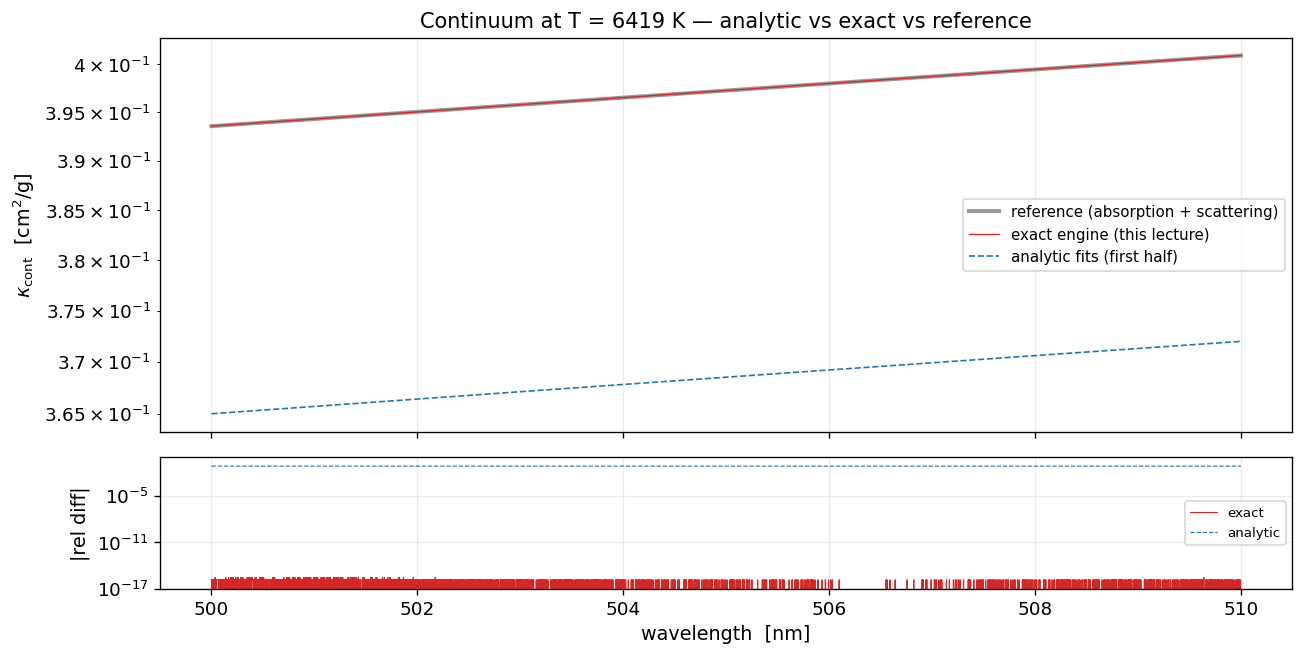

In [41]:
fig, (ax, axr) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})

ref_tot = cabs_ref[layer_p] + cscat_ref[layer_p]
exact_tot = absorption[layer_p] + scattering[layer_p]

# top panel: the three continua on a log opacity axis
ax.plot(wlk, ref_tot,   color="0.6", lw=2.4, label="reference (absorption + scattering)")
ax.plot(wlk, exact_tot, color="C3", lw=0.8, label="exact engine (this lecture)")
ax.plot(wlk, analytic_p, color="C0", lw=1.0, ls="--", label="analytic fits (first half)")
ax.set_yscale("log")
ax.set_ylabel(r"$\kappa_{\rm cont}$  [cm$^2$/g]")
ax.set_title(f"Continuum at T = {Tk[layer_p]:.0f} K — analytic vs exact vs reference")
ax.legend(loc="center right", fontsize=9)

# bottom panel: each build's relative difference from the reference
rel_exact = np.abs(exact_tot - ref_tot) / np.abs(ref_tot)
rel_anal = np.abs(analytic_p - ref_tot) / np.abs(ref_tot)
axr.semilogy(wlk, np.maximum(rel_exact, 1e-18), color="C3", lw=0.7, label="exact")
axr.semilogy(wlk, np.maximum(rel_anal, 1e-18), color="C0", lw=0.7, ls="--", label="analytic")
axr.set_xlabel("wavelength  [nm]")
axr.set_ylabel("|rel diff|")

# the analytic residual runs ~1e-2 to 1e-1 here; carry the upper limit to 1e0 so it is
# shown clearly rather than clipped against the top edge of the panel
axr.set_ylim(1e-17, 1e0)
axr.legend(loc="center right", fontsize=8)

fig.tight_layout(); plt.show()

The exact-engine curve lies on the reference and its residual sits at the floating-point floor; the analytic fit follows the same shape but stays a few percent away across the window. That gap — a few percent in the median over the spectrum-forming layers, larger at this particular layer — is precisely what the tabulated cross-sections close. The continuum is reproduced to machine precision where it forms.

## Synthesis: what you built and where it goes

You turned the equation of state into an opacity, twice. The first half built the **physics**: the visible continuum of a cool star is carried by the **H$^-$ ion**, whose abundance you computed from a Saha balance with $\chi=0.754\ \mathrm{eV}$ and whose **bound-free and free-free** absorption you evaluated with the John (1988) analytic fits, reproducing the reference to a few percent; the photospheric **scattering** is Rayleigh off neutral hydrogen, not Thomson, and only a percent-level floor.

The second half supplied the **engine**. Replacing each analytic fit with a direct evaluation of the production cross-section table — H$^-$ bound-free by `MAP1`, H$^-$ free-free by two nested linear interpolations, H I by the Karzas–Latter tables and the Coulomb Gaunt factor, Rayleigh by the Gavrila $G^2$ tables, Thomson by the classical electron cross-section, and the minor absorbers each by its own gated cross-section — and stitching the result together with the engine's edge-triplet grid and 3-point Lagrange interpolation, the continuum reproduces the reference to **machine precision** through the entire photosphere. The $\sim$2.4% gap of the analytic half is exactly the detail those tables carry.

This smooth continuum is the canvas, now exact. In Lecture 4 we paint the first spectral line onto it — a sharp, deep spike of extra opacity at one wavelength — and learn the profile that every line shares.

## Summary

- Continuous **extinction = true absorption + scattering**; only absorption carries the stimulated-emission factor $1-e^{-h\nu/kT}$ and thermalises ($S=B$).
- **H$^-$** dominates the visible continuum of cool stars; its density follows a Saha balance with $\chi=0.754\ \mathrm{eV}$ and scales with $n_e$ — the same population both halves use.
- The **John (1988)** bound-free and free-free fits, with Rayleigh ($\propto\lambda^{-4}$) and Thomson scattering, reproduce the reference continuum to a few percent — the right level for intuition.
- The production engine instead evaluates each source from a **tabulated cross-section**, samples **three frequencies per continuum edge interval**, and reconstructs $\log_{10}\kappa(\lambda)$ by a **3-point Lagrange parabola**.
- **H$^-$** supplies $\sim$92% of the absorption (bound-free by `MAP1`, free-free by two nested linear interps); **H I** (Karzas–Latter + COULFF) and the minor terms (H$_2^+$, He, C/Mg/Al/Si edges) make up the rest; **scattering** is Rayleigh off H I (Gavrila $G^2$, $\sim$63%) plus grey Thomson ($\sim$36%), kept separate.
- The rebuilt engine reproduces the reference continuum to a **median of exactly zero** and is **machine-precise across the photosphere** ($T<8000\,$K); the one larger residual ($9\times10^{-5}$) lives in the deep hot layers below the photosphere and reflects a known change in the reference's high-$T$ He I free-free formula, not a porting error.

## Practice exercises

**1. The H$^-$ peak.** Plot the John bound-free cross-section $\sigma_{\rm bf}(\lambda)$ across $0.2$–$1.7\ \mathrm{\mu m}$. Where does it peak, and what happens beyond the threshold $\lambda_0 = 1.6419\ \mathrm{\mu m}$? Why does the free-free term matter more in the infrared?

**2. Metal-poor continuum.** H$^-$ opacity scales with $n_e$, which (Lecture 2) scales with metal abundance. Recompute the analytic $\kappa_{\rm H^-}$ with $n_e$ reduced by a factor of ten and describe how the continuum brightness and the depth of the $\tau=2/3$ layer would change. Why are metal-poor stars said to have "more transparent" atmospheres?

**3. The dominant term.** Re-run `compute_continuum` with only `hminus_opacity` contributing (zero the others) and compare to the full reference at a photospheric layer. How large is the residual, and where in the window is it worst? Relate the answer to the $\sim$8% that the minor terms supply.

**4. The interpolation matters.** Replace the 3-point Lagrange reconstruction with a simple two-point linear interpolation in $\log_{10}\kappa$ between the two edges (drop the half-point). By how much does the continuum shift across the window, and why is the parabola needed for bit-level agreement?

**5. The deep-layer residual.** Confirm that the $9\times10^{-5}$ discrepancy lives only in the layers with $T > 20{,}000\,$K by masking the comparison on temperature. Then argue, from the optical depth at which the 500–510 nm continuum forms, why this residual cannot affect the emergent solar spectrum.

## Further reading

- **John, T. L. (1988). [*Continuous absorption by the negative hydrogen ion reconsidered*](https://ui.adsabs.harvard.edu/abs/1988A%26A...193..189J/abstract), A&A, 193, 189.** The bound-free and free-free analytic fits used in the first half, fit to the same cross-sections the engine tabulates.
- **Kurucz, R. L. (1970). *SAO Special Report* 309 (ATLAS).** The original continuous-opacity routines — `HMINOP`, `HOP`, `HRAYOP`, `COULFF` — whose tables and evaluation order the engine half reproduces.
- **Gavrila, M. (1967). *Phys. Rev.* 163, 147.** The Rayleigh-scattering polarisability factor $G(\nu)$ for atomic hydrogen, tabulated here as `HRAYOP_GAVRILA*`.
- **Karzas, W. J. & Latter, R. (1961). *ApJ Suppl.* 6, 167.** The hydrogenic bound-free and free-free Gaunt factors behind the `xkarsas` lookup and the Coulomb free-free table.
- **Wildt, R. (1939). *Negative Ions of Hydrogen and the Opacity of Stellar Atmospheres*, ApJ, 90, 611.** The paper that identified H$^-$ as the key opacity source.
- **Gray, D. F. (2005). *The Observation and Analysis of Stellar Photospheres*, 3rd ed., Cambridge.** Chapter 8 on continuous opacity, with the H$^-$ and scattering terms worked through.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The implementation our reference continuum is computed with.